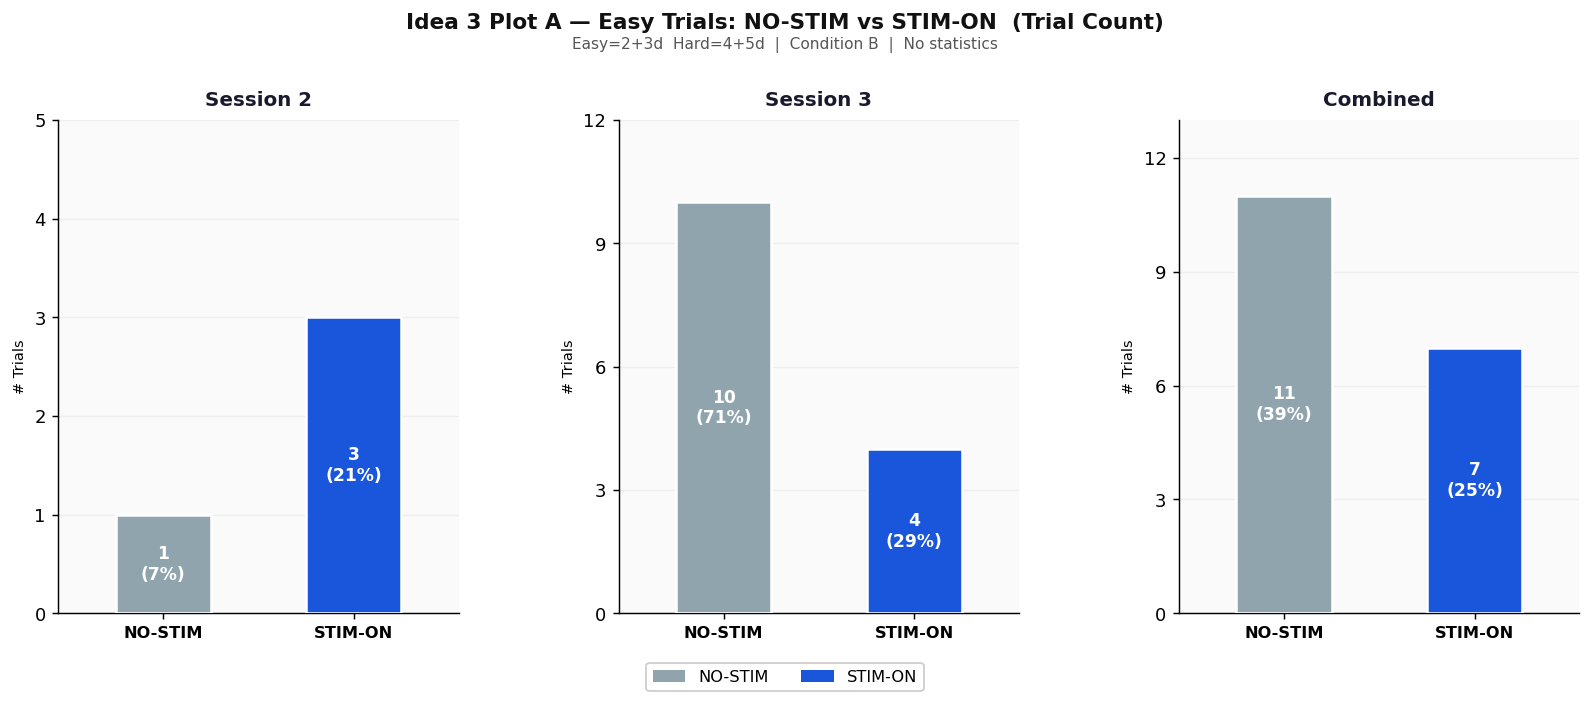

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\idea_3_A_easy_count.png


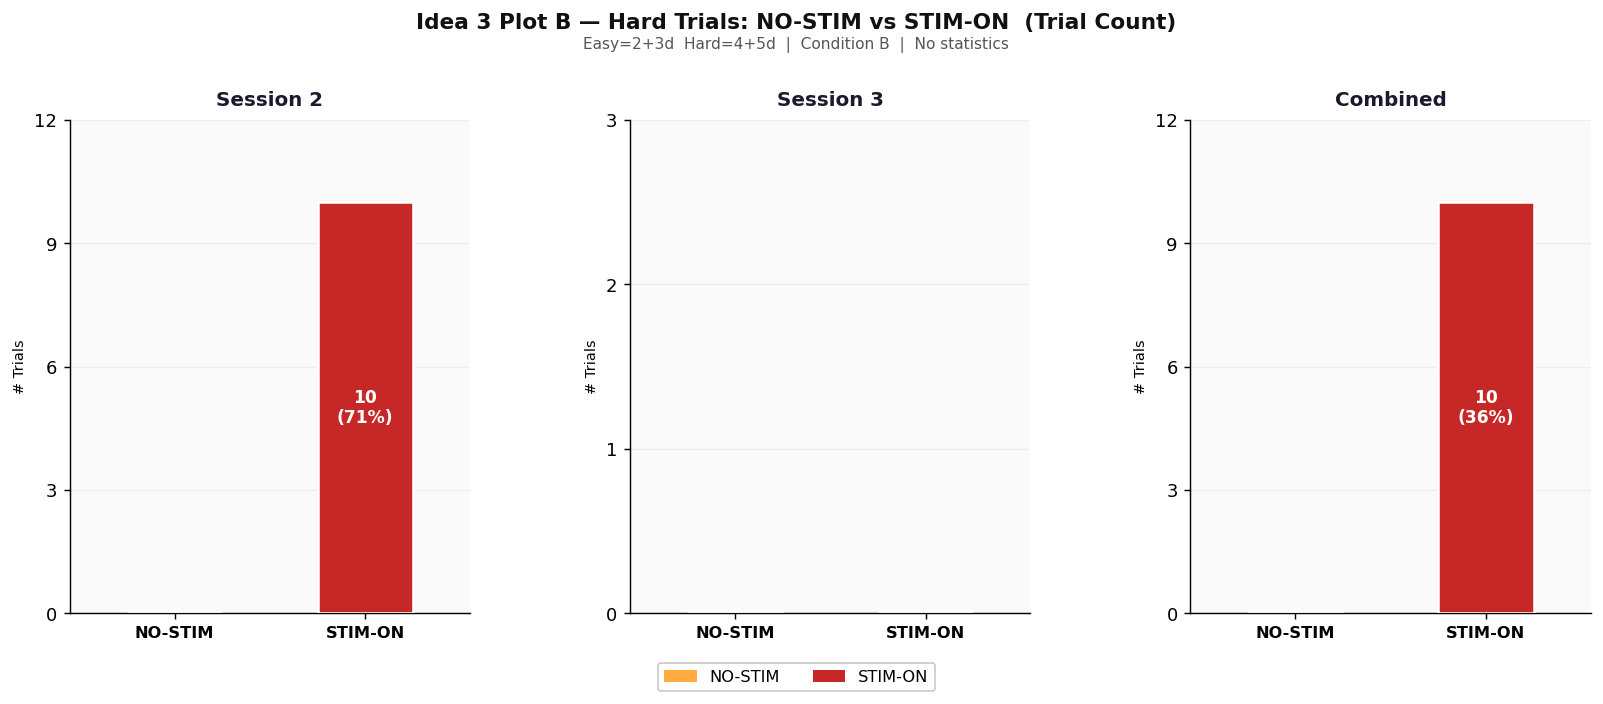

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\idea_3_B_hard_count.png


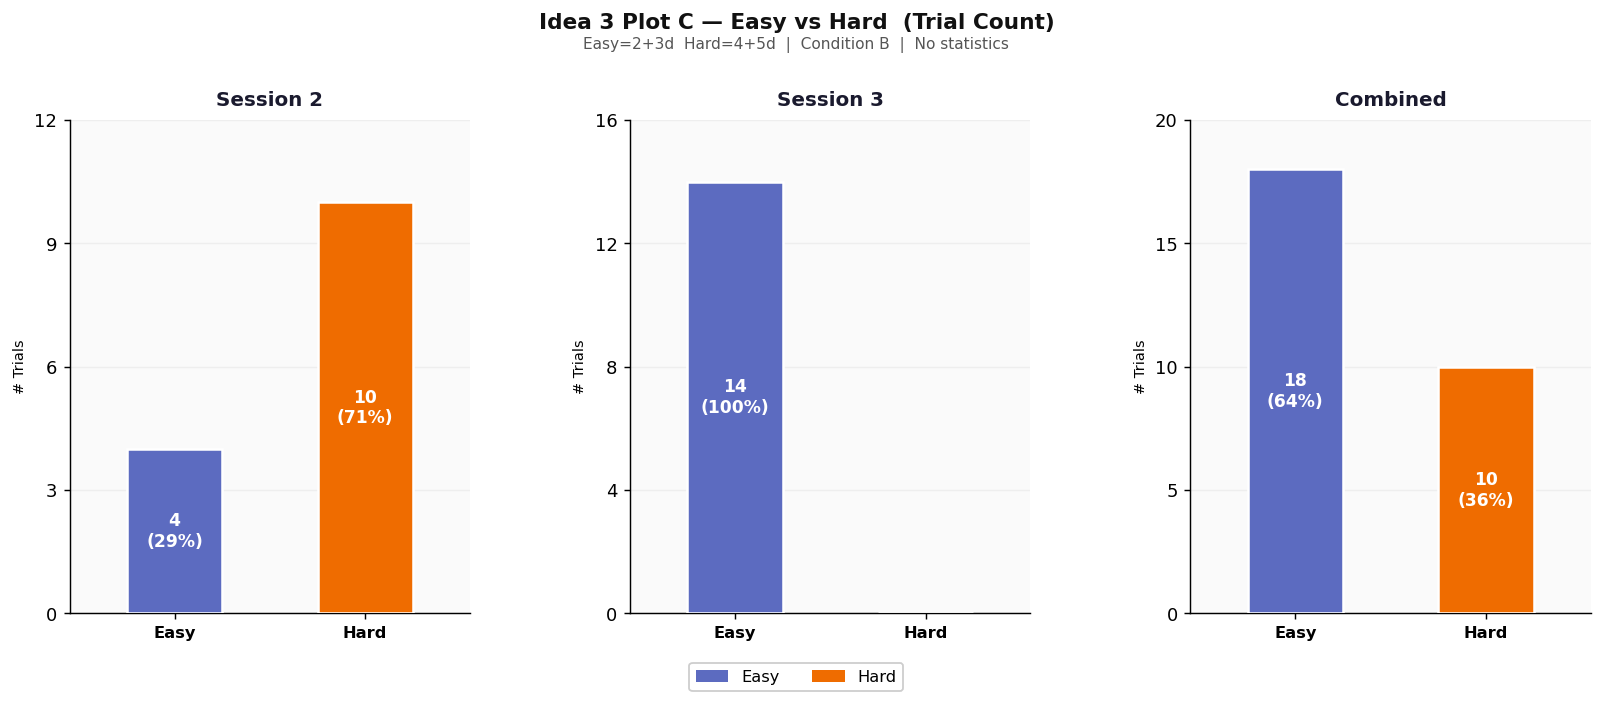

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\idea_3_C_easy_vs_hard_count.png


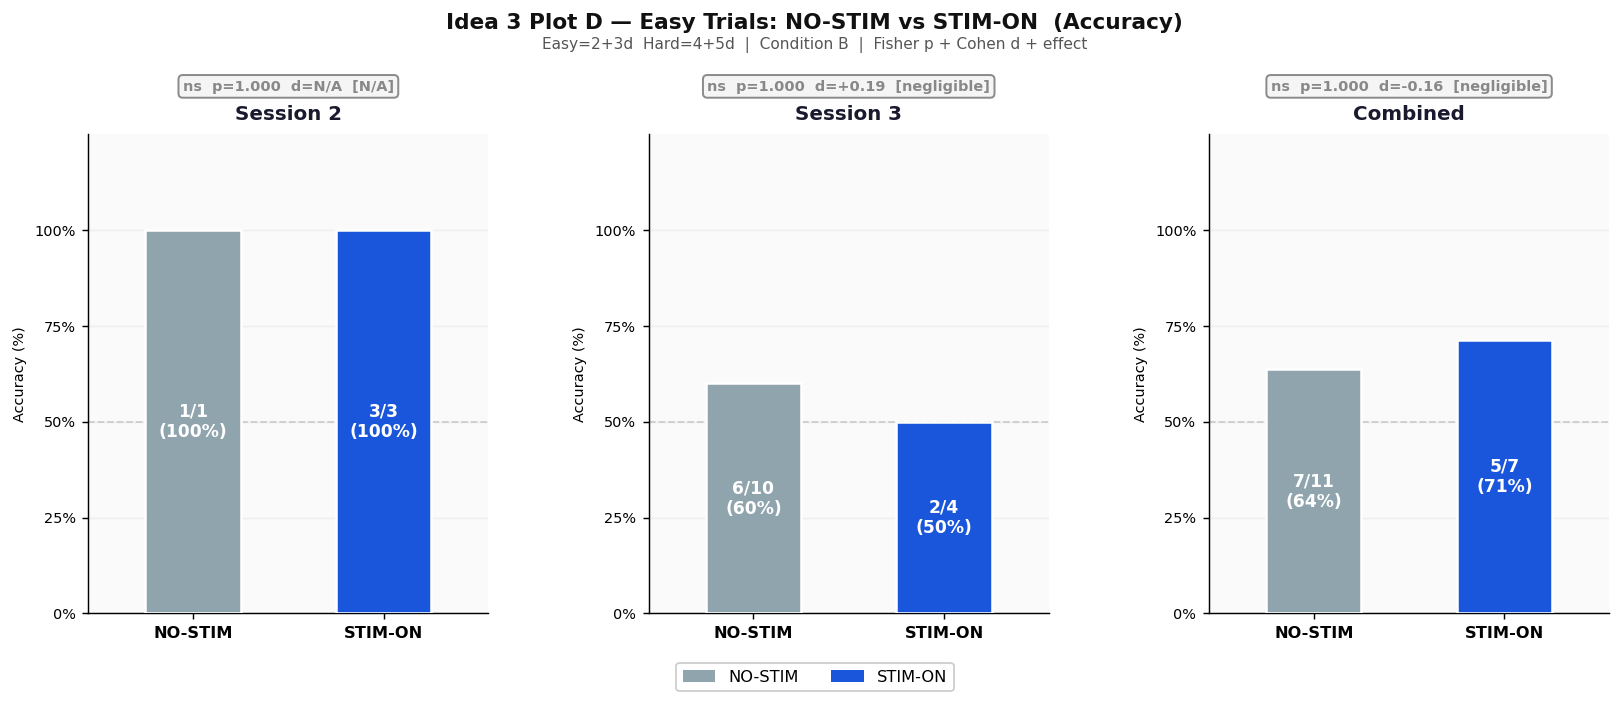

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\idea_3_D_easy_acc.png


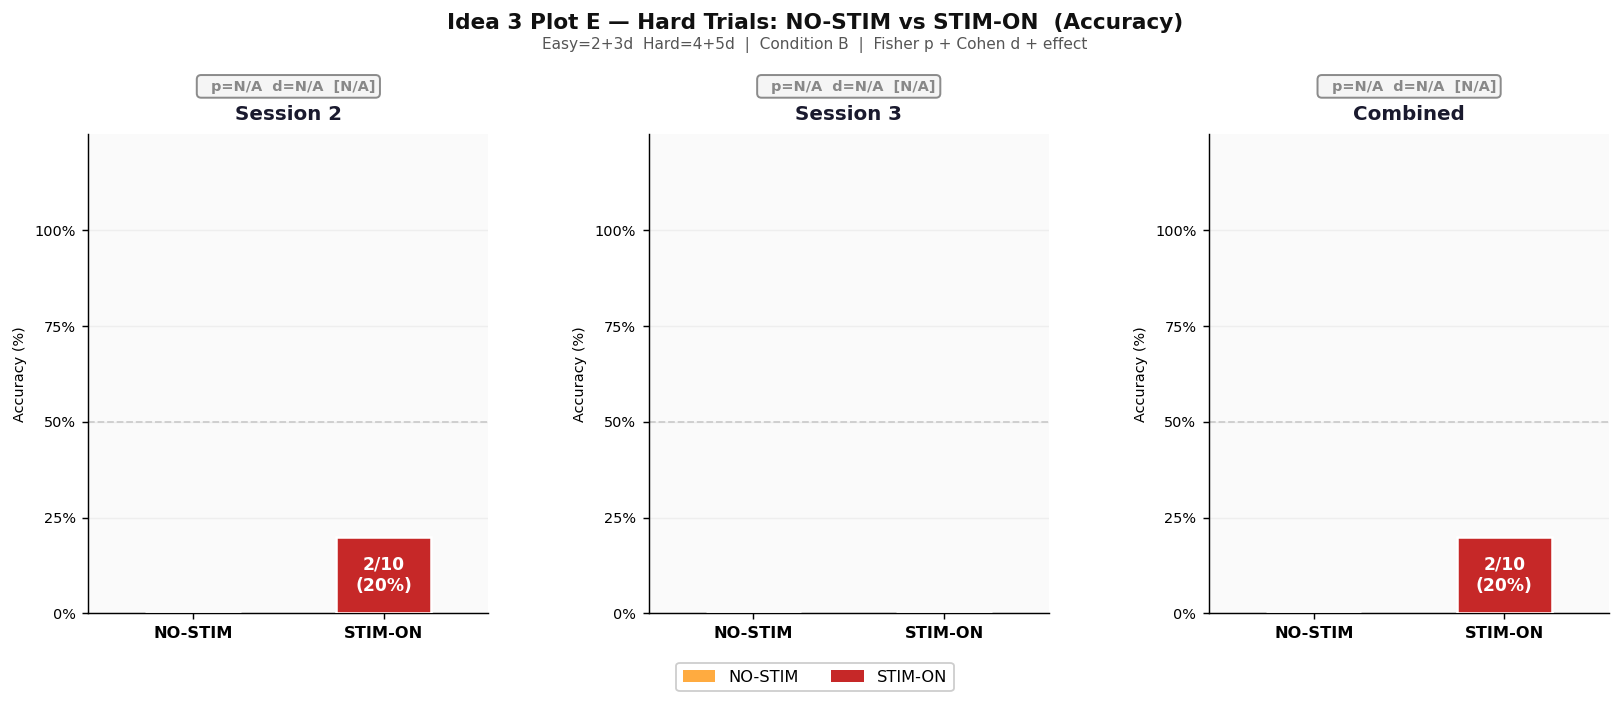

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\idea_3_E_hard_acc.png


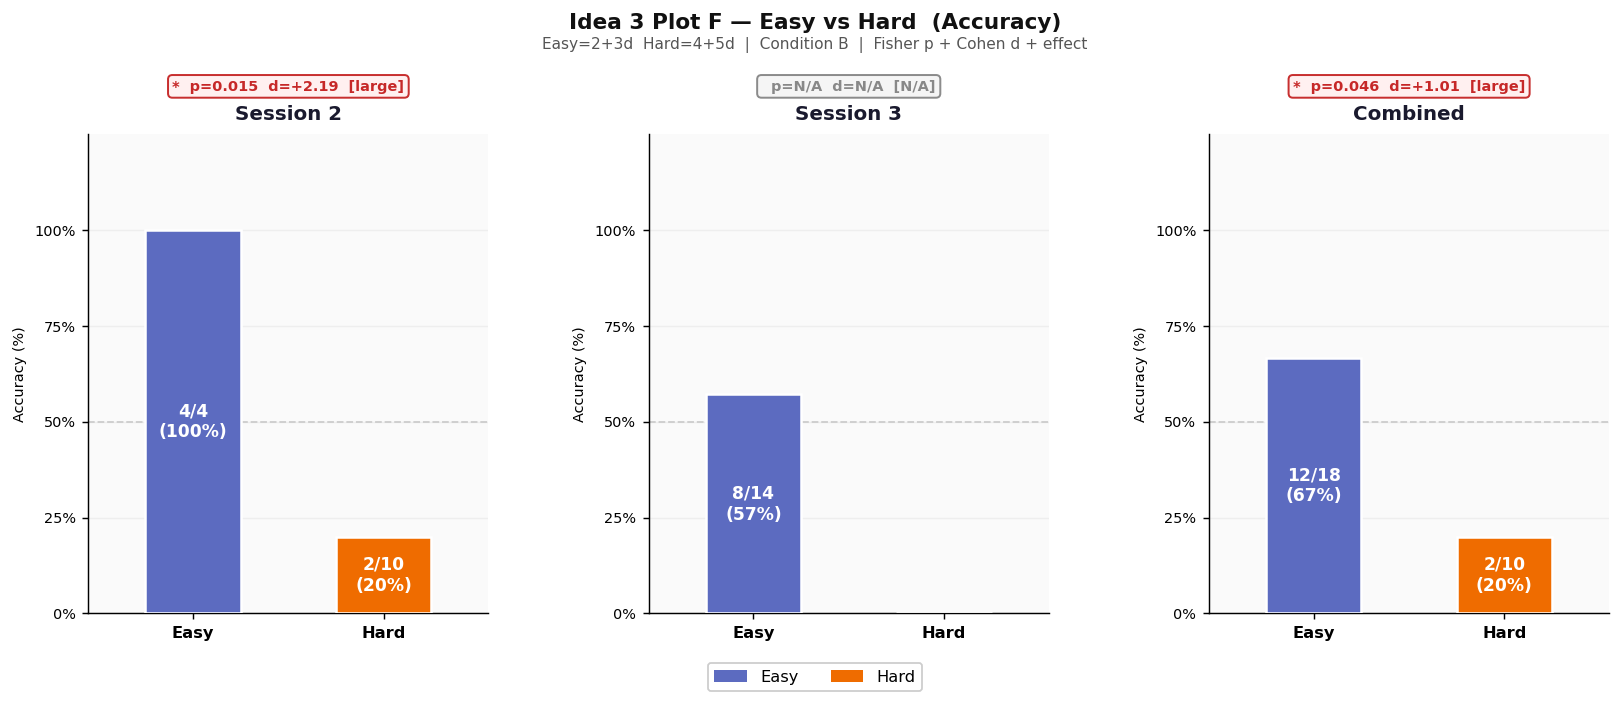

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\idea_3_F_easy_vs_hard_acc.png


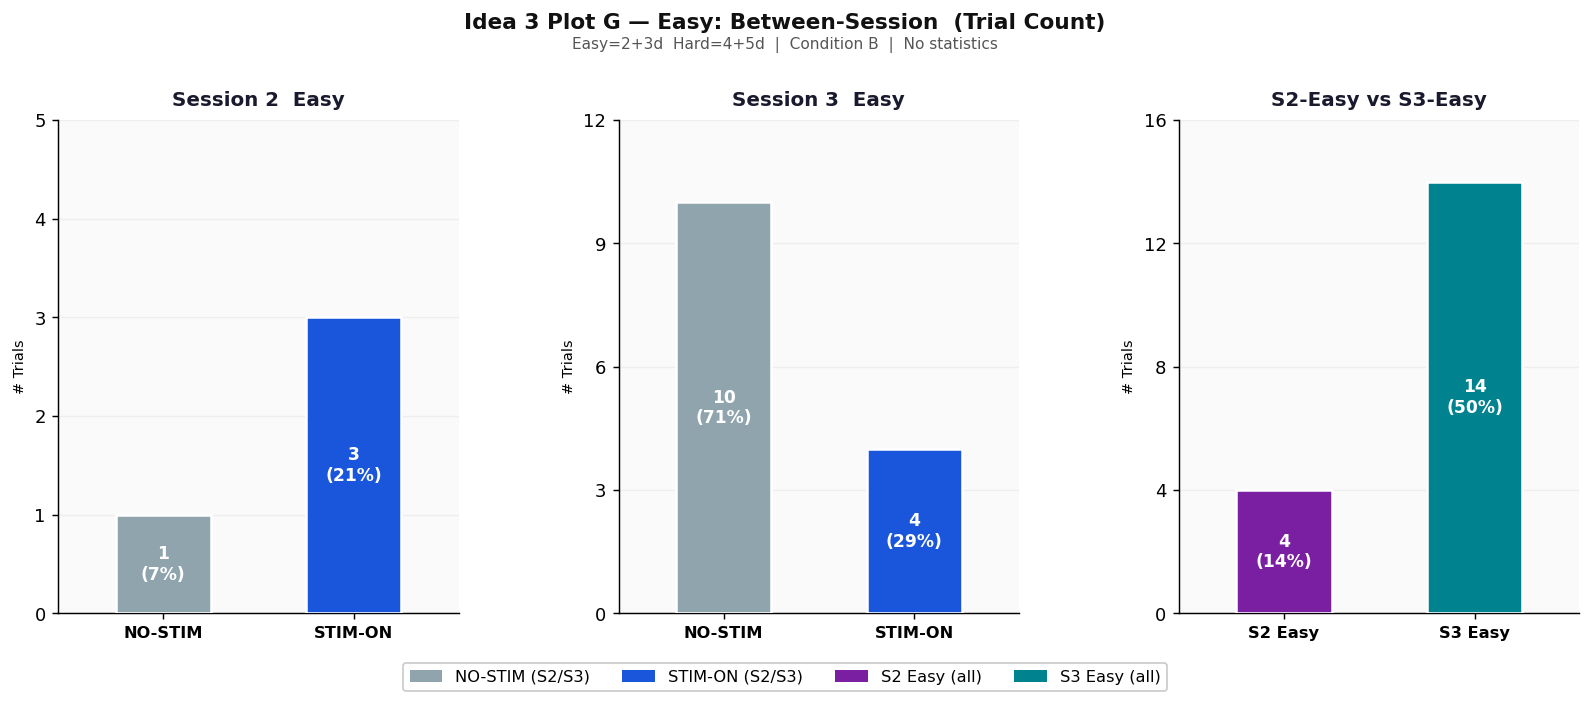

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\idea_3_G_easy_between_count.png


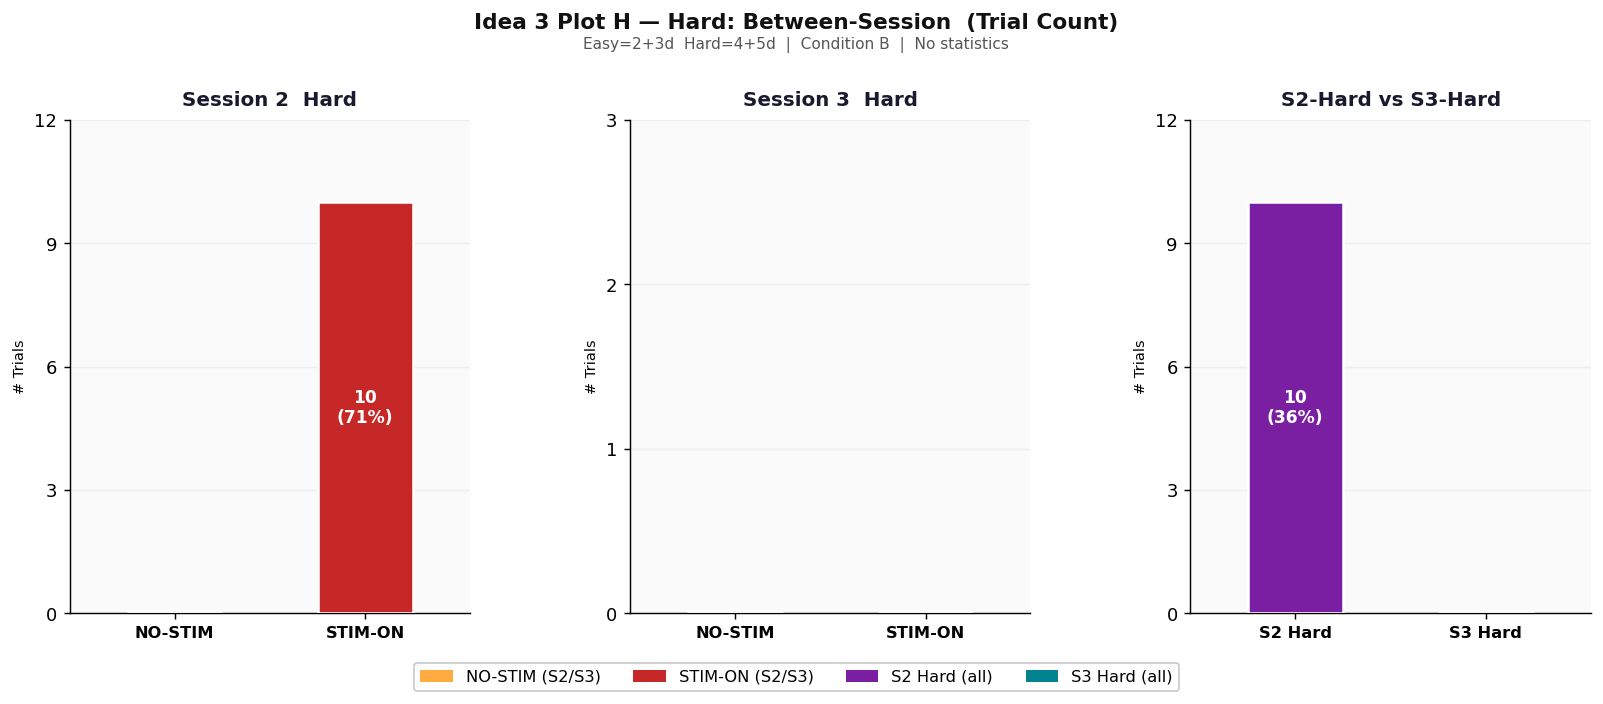

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\idea_3_H_hard_between_count.png


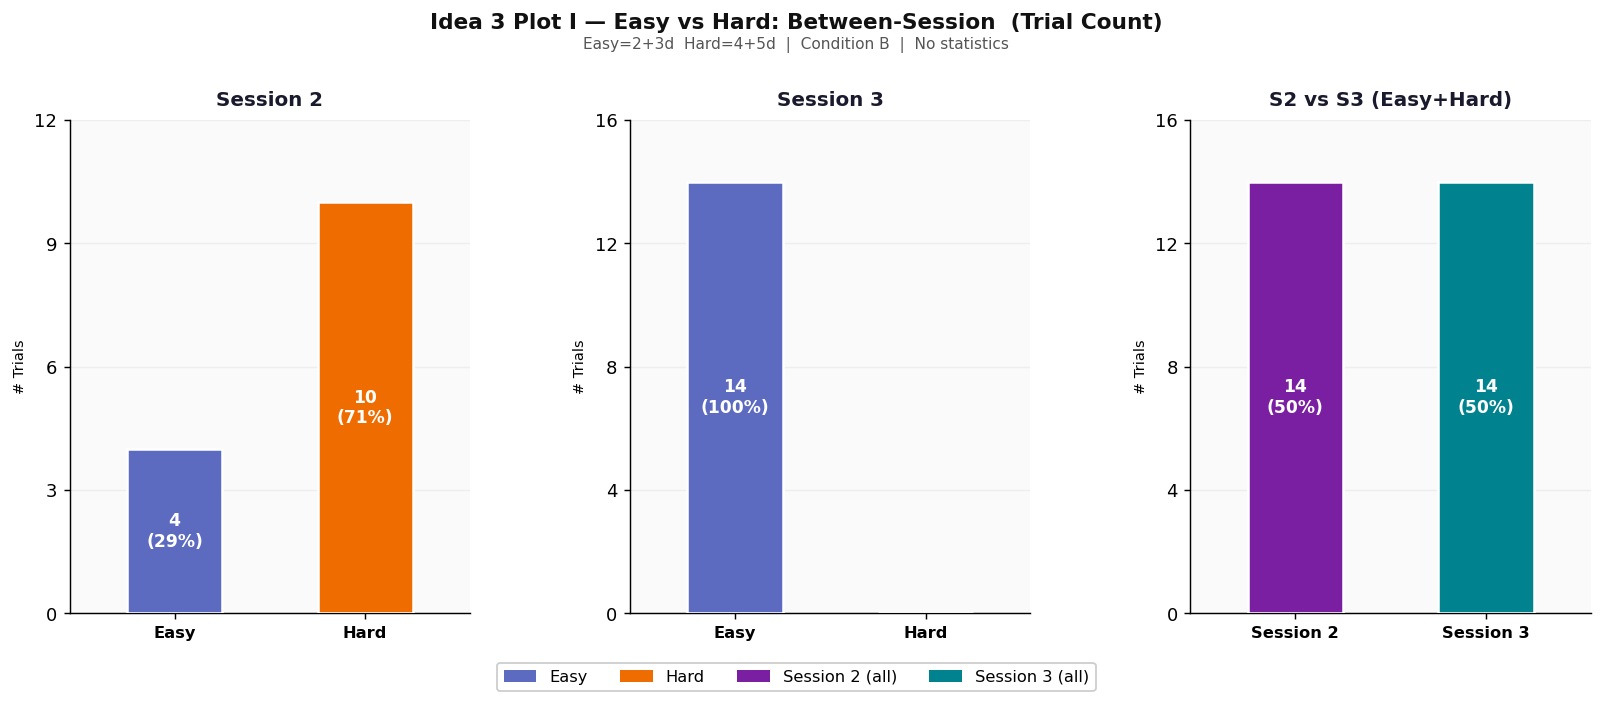

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\idea_3_I_between_easy_hard_count.png


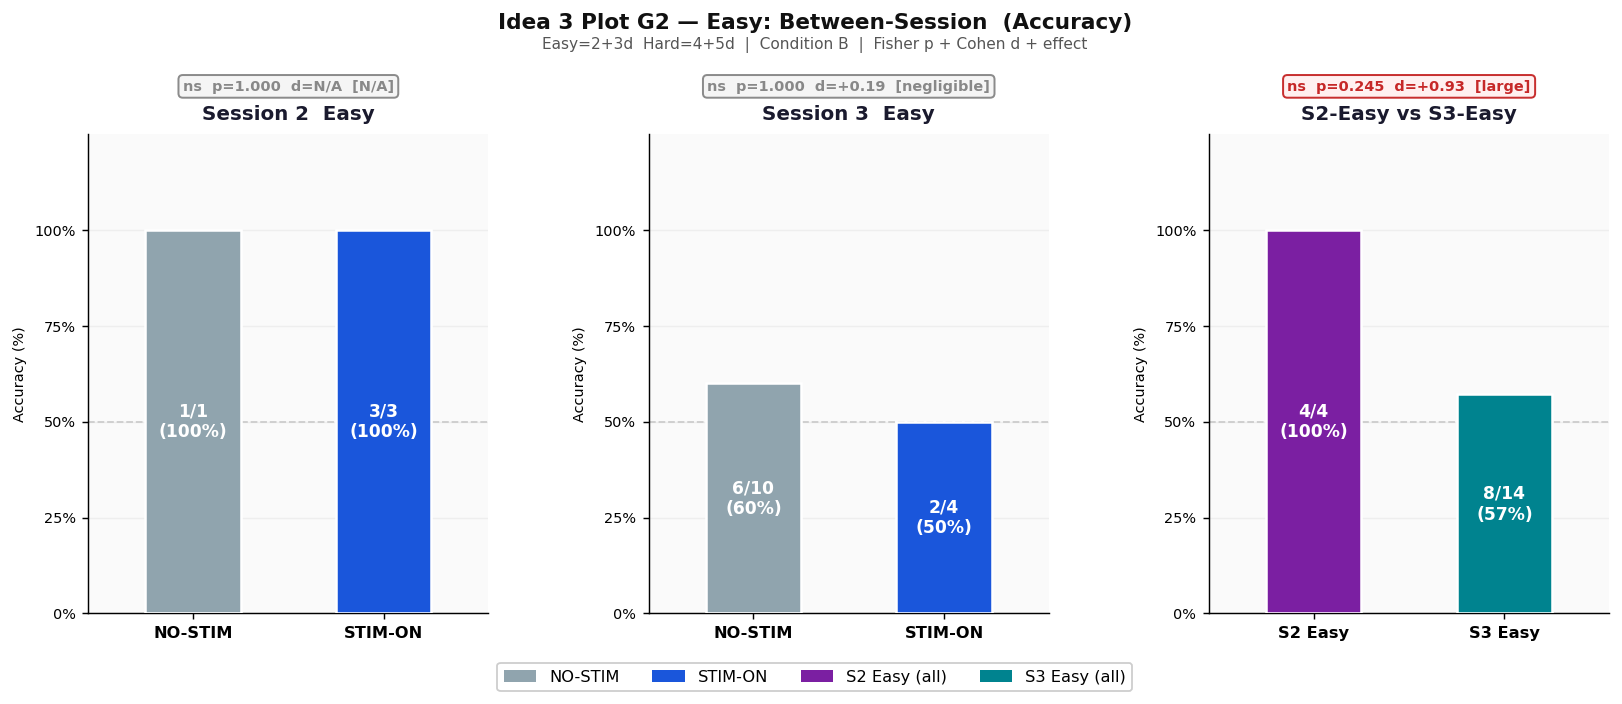

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\idea_3_G2_easy_between_acc.png


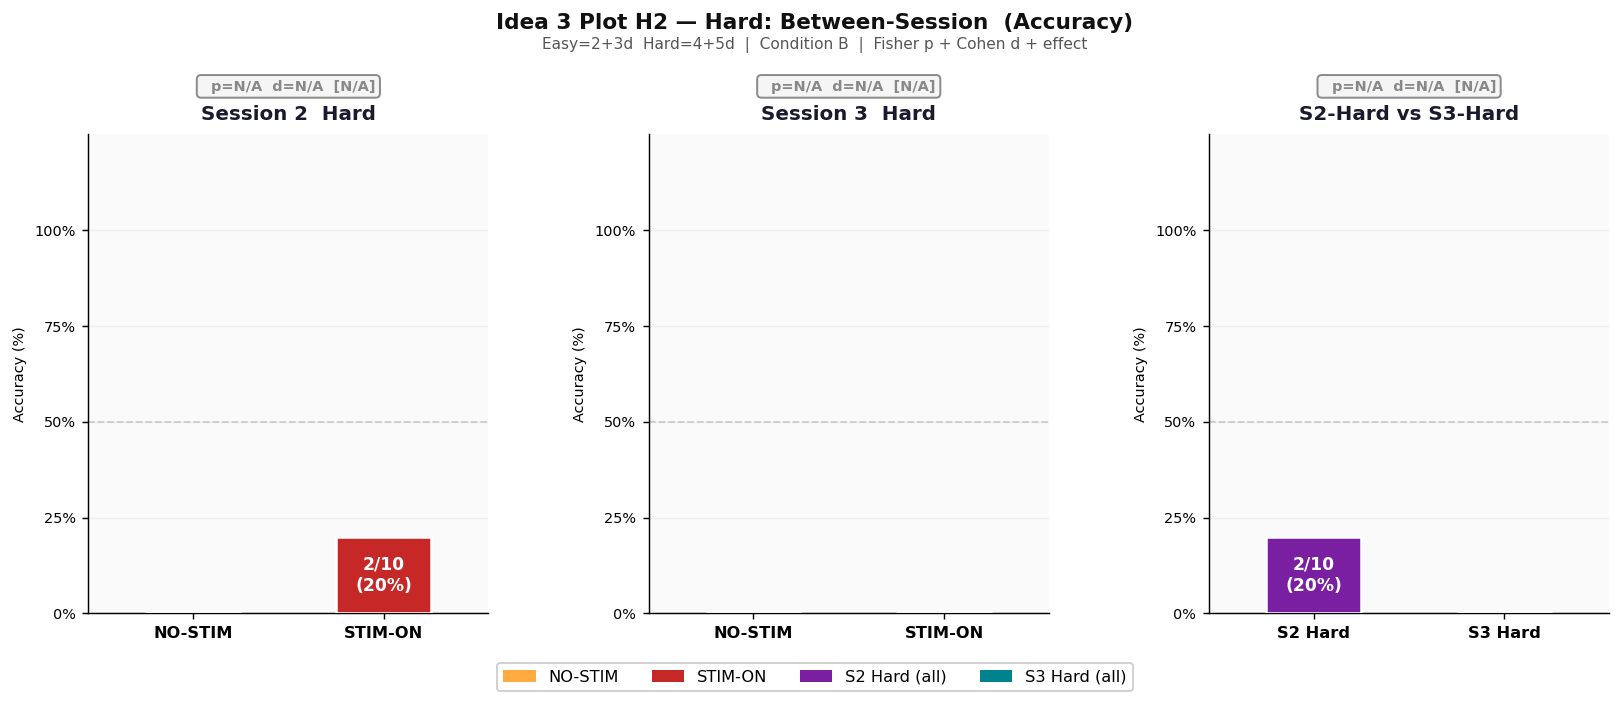

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\idea_3_H2_hard_between_acc.png


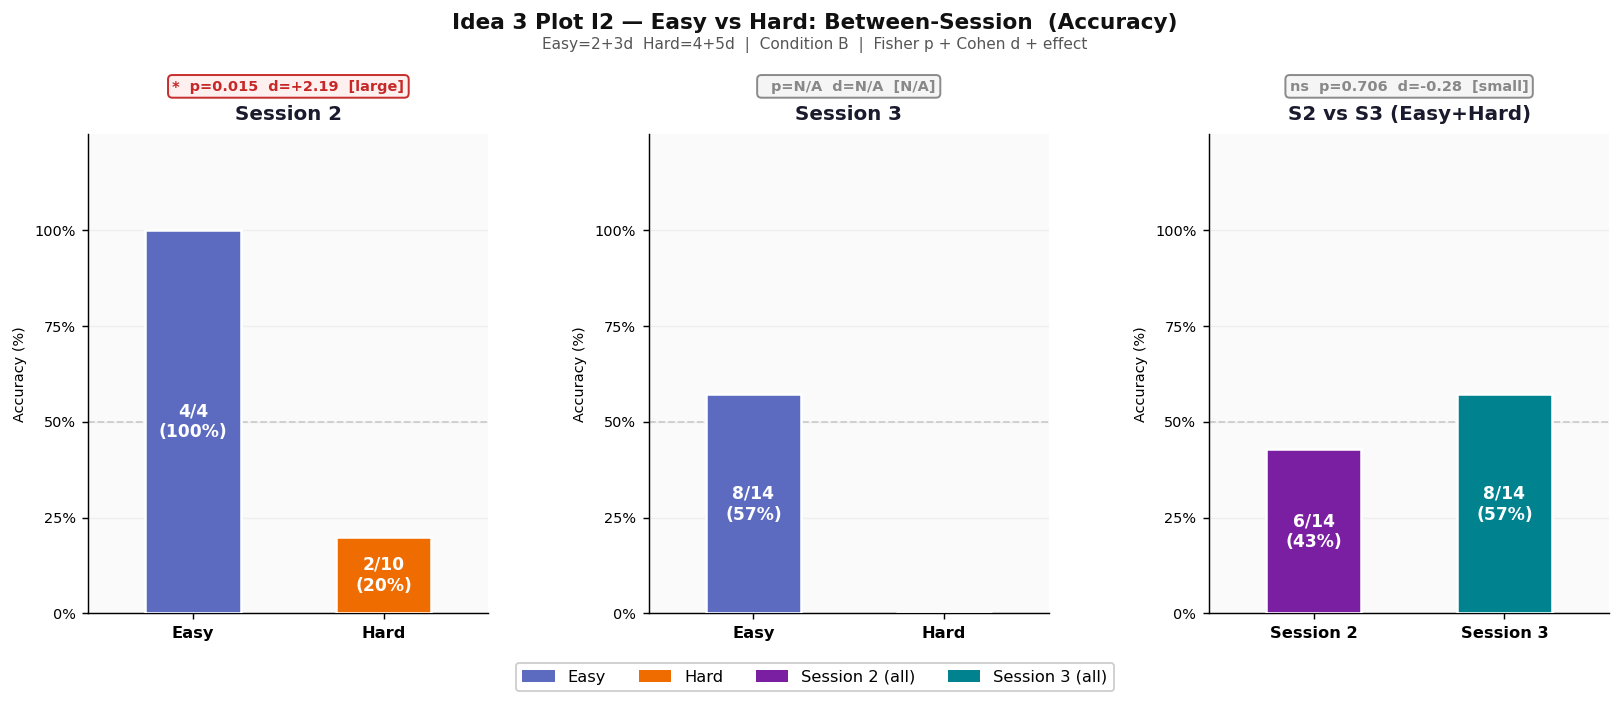

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\idea_3_I2_between_easy_hard_acc.png


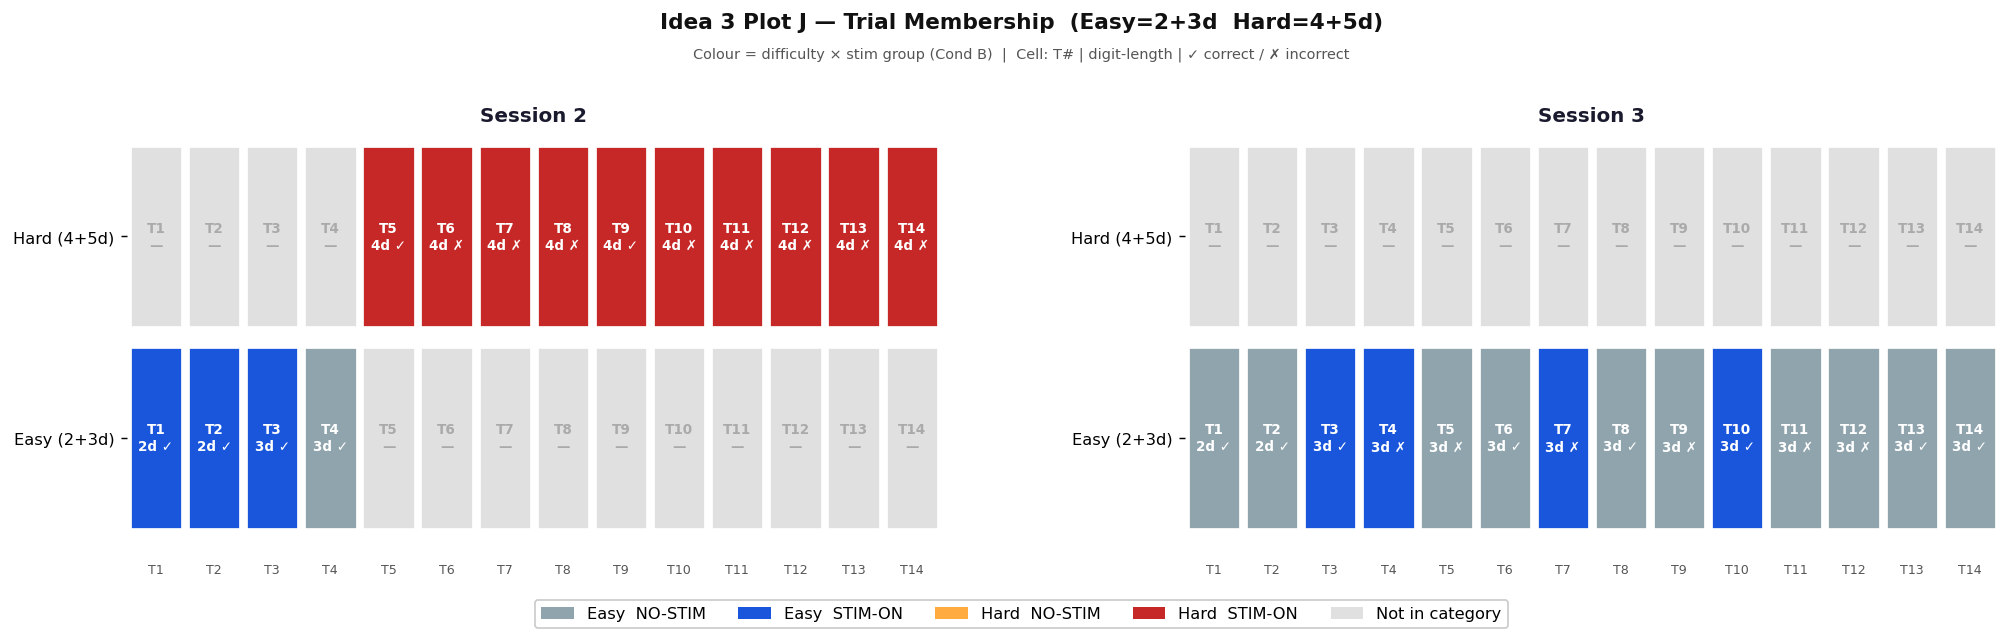

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\idea_3_J_membership.png


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# IDEA 3  —  Easy = {2,3} digits  |  Hard = {4,5} digits
#            Condition B classification throughout
# ══════════════════════════════════════════════════════════════════════════════

import textwrap, matplotlib.patches as mpatches

C_EASY_NO = '#90A4AE'
C_EASY_ON = '#1A56DB'
C_HARD_NO = '#FFAB40'
C_HARD_ON = '#C62828'
C_S2      = '#7B1FA2'   # purple  — Session 2
C_S3      = '#00838F'   # teal    — Session 3


def dg(trials, easy_set, hard_set):
    """Split trials into easy/hard × no-stim/stim-on (Condition B)."""
    key = 'stim_present_condB'
    return dict(
        easy_no = [t for t in trials if t['digits'] in easy_set and not t[key]],
        easy_on = [t for t in trials if t['digits'] in easy_set and     t[key]],
        hard_no = [t for t in trials if t['digits'] in hard_set and not t[key]],
        hard_on = [t for t in trials if t['digits'] in hard_set and     t[key]],
    )


def _sbox(ax, res, y_ax=1.09, fs=8.5):
    p_v = res['p_value']; d_v = res['cohens_d']
    eff = effect_label(d_v); sig = sig_stars(p_v)
    p_str = f'p={p_v:.3f}' if not np.isnan(p_v) else 'p=N/A'
    d_str = f'd={d_v:+.2f}' if not np.isnan(d_v) else 'd=N/A'
    notable = (not np.isnan(p_v) and p_v < 0.05) or \
              (not np.isnan(d_v) and abs(d_v) >= 0.8)
    fc = '#FFF0F0' if notable else '#F5F5F5'
    ec = '#C62828' if notable else '#888888'
    ax.text(0.5, y_ax, f'{sig}  {p_str}  {d_str}  [{eff}]',
            transform=ax.transAxes, ha='center', va='center',
            fontsize=fs, fontweight='bold', color=ec,
            bbox=dict(boxstyle='round,pad=0.3', fc=fc, ec=ec, lw=1.1, alpha=0.97))


def _bar2(ax, g1, g2, c1, c2, xl, show_stats, n_total=None, y_type='count'):
    """Draw a clean 2-bar subplot. y_type='count' or 'acc'."""
    if y_type == 'count':
        v1, v2 = len(g1), len(g2)
        ax.bar([0,1], [v1,v2], width=0.5, color=[c1,c2],
               edgecolor='white', linewidth=1.4, zorder=3)
        n_tot = n_total or max(v1+v2, 1)
        for xi, nv in [(0,v1),(1,v2)]:
            pct = 100*nv/n_tot if n_tot else 0
            if nv > 0:
                ax.text(xi, nv/2, f'{nv}\n({pct:.0f}%)',
                        ha='center', va='center',
                        fontsize=9.5, fontweight='bold', color='white', zorder=8)
        max_y = max(v1, v2, 1) + 2
        ax.set_ylim(0, max_y)
        ax.set_yticks(range(0, int(max_y)+1, max(1, int(max_y)//4)))
        ax.set_ylabel('# Trials', fontsize=8)
    else:
        res = run_comparison(g1, g2, '')
        p1 = res['pct_no'] if not np.isnan(res['pct_no']) else 0.0
        p2 = res['pct_on'] if not np.isnan(res['pct_on']) else 0.0
        ax.bar([0,1], [p1,p2], width=0.5, color=[c1,c2],
               edgecolor='white', linewidth=1.4, zorder=3)
        for xi, pct, nc, nt in [(0,p1,res['correct_no'],res['n_no_stim']),
                                  (1,p2,res['correct_on'],res['n_stim'])]:
            if nt > 0:
                ax.text(xi, max(pct/2,5), f'{nc}/{nt}\n({pct:.0f}%)',
                        ha='center', va='center',
                        fontsize=9.5, fontweight='bold', color='white', zorder=8)
        ax.axhline(50, color='#cccccc', lw=1.0, ls='--', zorder=1)
        ax.set_ylim(0, 125)
        ax.set_yticks([0,25,50,75,100])
        ax.set_yticklabels(['0%','25%','50%','75%','100%'], fontsize=8)
        ax.set_ylabel('Accuracy (%)', fontsize=8)
        if show_stats:
            _sbox(ax, res, y_ax=1.10, fs=8)

    ax.set_xticks([0,1])
    ax.set_xticklabels(xl, fontsize=9, fontweight='bold')
    ax.set_xlim(-0.55, 1.55)
    ax.yaxis.grid(True, color='#eeeeee', zorder=0)
    ax.set_axisbelow(True)
    ax.set_facecolor('#FAFAFA')
    return run_comparison(g1, g2, '') if y_type=='acc' else None


def _fig1x3(title, subtitle, col_titles, legend_handles, tight_top=0.82):
    fig, axes = plt.subplots(1, 3, figsize=(13, 5.5), facecolor='white')
    fig.subplots_adjust(wspace=0.40, top=tight_top, bottom=0.13,
                        left=0.07, right=0.97)
    fig.suptitle(title, fontsize=12, fontweight='bold', color='#111', y=0.97)
    fig.text(0.5, 0.92, subtitle, ha='center', fontsize=8.5, color='#555')
    for ax, ct in zip(axes, col_titles):
        ax.set_title(ct, fontsize=11, fontweight='bold', color='#1A1A2E', pad=8)
    if legend_handles:
        fig.legend(handles=legend_handles, loc='lower center', ncol=len(legend_handles),
                   fontsize=9, framealpha=0.97, facecolor='white',
                   edgecolor='#ccc', bbox_to_anchor=(0.5, 0.01))
    return fig, axes


def save_fig(fig, path):
    fig.savefig(path, bbox_inches='tight', dpi=160, facecolor='white')
    plt.show(); plt.close(fig)
    print(f'Saved -> {path}')


# ─────────────────────────────────────────────────────────────────────────────
def run_idea(easy_set, hard_set, idea_tag, save_dir):
    easy_str = '+'.join(str(d) for d in sorted(easy_set))
    hard_str = '+'.join(str(d) for d in sorted(hard_set))
    tag_str  = f'Easy={easy_str}d  Hard={hard_str}d'
    it = idea_tag  # short

    s2g = dg(all_s2,       easy_set, hard_set)
    s3g = dg(all_s3,       easy_set, hard_set)
    cg  = dg(all_combined, easy_set, hard_set)

    # Total within each session for percentage denominator
    n_s2 = len([t for t in all_s2 if t['digits'] in easy_set|hard_set])
    n_s3 = len([t for t in all_s3 if t['digits'] in easy_set|hard_set])
    n_cb = n_s2 + n_s3

    leg_stim = [mpatches.Patch(facecolor=C_EASY_NO, label='NO-STIM'),
                mpatches.Patch(facecolor=C_EASY_ON, label='STIM-ON')]
    leg_hard = [mpatches.Patch(facecolor=C_HARD_NO, label='NO-STIM'),
                mpatches.Patch(facecolor=C_HARD_ON, label='STIM-ON')]
    leg_eh   = [mpatches.Patch(facecolor='#5C6BC0', label='Easy'),
                mpatches.Patch(facecolor='#EF6C00', label='Hard')]
    leg_sess = [mpatches.Patch(facecolor=C_S2, label='Session 2'),
                mpatches.Patch(facecolor=C_S3, label='Session 3')]

    # ── PLOT A — Easy: S2 | S3 | Combined  (trial count, no stats) ──────────
    fig, axes = _fig1x3(
        f'{it} Plot A — Easy Trials: NO-STIM vs STIM-ON  (Trial Count)',
        f'{tag_str}  |  Condition B  |  No statistics',
        ['Session 2', 'Session 3', 'Combined'],
        leg_stim)
    for ax, grp, nt in zip(axes, [s2g,s3g,cg], [n_s2,n_s3,n_cb]):
        _bar2(ax, grp['easy_no'], grp['easy_on'],
              C_EASY_NO, C_EASY_ON, ['NO-STIM','STIM-ON'],
              show_stats=False, n_total=nt, y_type='count')
    save_fig(fig, save_dir / f'{it.lower().replace(" ","_")}_A_easy_count.png')

    # ── PLOT B — Hard: S2 | S3 | Combined  (trial count, no stats) ──────────
    fig, axes = _fig1x3(
        f'{it} Plot B — Hard Trials: NO-STIM vs STIM-ON  (Trial Count)',
        f'{tag_str}  |  Condition B  |  No statistics',
        ['Session 2', 'Session 3', 'Combined'],
        leg_hard)
    for ax, grp, nt in zip(axes, [s2g,s3g,cg], [n_s2,n_s3,n_cb]):
        _bar2(ax, grp['hard_no'], grp['hard_on'],
              C_HARD_NO, C_HARD_ON, ['NO-STIM','STIM-ON'],
              show_stats=False, n_total=nt, y_type='count')
    save_fig(fig, save_dir / f'{it.lower().replace(" ","_")}_B_hard_count.png')

    # ── PLOT C — Easy vs Hard: S2 | S3 | Combined  (trial count, no stats) ──
    fig, axes = _fig1x3(
        f'{it} Plot C — Easy vs Hard  (Trial Count)',
        f'{tag_str}  |  Condition B  |  No statistics',
        ['Session 2', 'Session 3', 'Combined'],
        leg_eh)
    for ax, grp, nt in zip(axes, [s2g,s3g,cg], [n_s2,n_s3,n_cb]):
        easy_all = grp['easy_no'] + grp['easy_on']
        hard_all = grp['hard_no'] + grp['hard_on']
        _bar2(ax, easy_all, hard_all,
              '#5C6BC0', '#EF6C00', ['Easy','Hard'],
              show_stats=False, n_total=nt, y_type='count')
    save_fig(fig, save_dir / f'{it.lower().replace(" ","_")}_C_easy_vs_hard_count.png')

    # ── PLOT D — Easy: S2 | S3 | Combined  (accuracy, with stats) ───────────
    fig, axes = _fig1x3(
        f'{it} Plot D — Easy Trials: NO-STIM vs STIM-ON  (Accuracy)',
        f'{tag_str}  |  Condition B  |  Fisher p + Cohen d + effect',
        ['Session 2', 'Session 3', 'Combined'],
        leg_stim, tight_top=0.80)
    for ax, grp in zip(axes, [s2g,s3g,cg]):
        _bar2(ax, grp['easy_no'], grp['easy_on'],
              C_EASY_NO, C_EASY_ON, ['NO-STIM','STIM-ON'],
              show_stats=True, y_type='acc')
    save_fig(fig, save_dir / f'{it.lower().replace(" ","_")}_D_easy_acc.png')

    # ── PLOT E — Hard: S2 | S3 | Combined  (accuracy, with stats) ───────────
    fig, axes = _fig1x3(
        f'{it} Plot E — Hard Trials: NO-STIM vs STIM-ON  (Accuracy)',
        f'{tag_str}  |  Condition B  |  Fisher p + Cohen d + effect',
        ['Session 2', 'Session 3', 'Combined'],
        leg_hard, tight_top=0.80)
    for ax, grp in zip(axes, [s2g,s3g,cg]):
        _bar2(ax, grp['hard_no'], grp['hard_on'],
              C_HARD_NO, C_HARD_ON, ['NO-STIM','STIM-ON'],
              show_stats=True, y_type='acc')
    save_fig(fig, save_dir / f'{it.lower().replace(" ","_")}_E_hard_acc.png')

    # ── PLOT F — Easy vs Hard: S2 | S3 | Combined  (accuracy, with stats) ───
    fig, axes = _fig1x3(
        f'{it} Plot F — Easy vs Hard  (Accuracy)',
        f'{tag_str}  |  Condition B  |  Fisher p + Cohen d + effect',
        ['Session 2', 'Session 3', 'Combined'],
        leg_eh, tight_top=0.80)
    for ax, grp in zip(axes, [s2g,s3g,cg]):
        easy_all = grp['easy_no'] + grp['easy_on']
        hard_all = grp['hard_no'] + grp['hard_on']
        _bar2(ax, easy_all, hard_all,
              '#5C6BC0', '#EF6C00', ['Easy','Hard'],
              show_stats=True, y_type='acc')
    save_fig(fig, save_dir / f'{it.lower().replace(" ","_")}_F_easy_vs_hard_acc.png')

    # ══ BETWEEN-SESSION COMPARISONS ════════════════════════════════════════

    # ── PLOT G — Easy NO-STIM vs STIM-ON: S2 Easy | S3 Easy | S2-Easy vs S3-Easy  (count)
    fig, axes = _fig1x3(
        f'{it} Plot G — Easy: Between-Session  (Trial Count)',
        f'{tag_str}  |  Condition B  |  No statistics',
        ['Session 2  Easy', 'Session 3  Easy', 'S2-Easy vs S3-Easy'],
        [mpatches.Patch(facecolor=C_EASY_NO, label='NO-STIM (S2/S3)'),
         mpatches.Patch(facecolor=C_EASY_ON, label='STIM-ON (S2/S3)'),
         mpatches.Patch(facecolor=C_S2, label='S2 Easy (all)'),
         mpatches.Patch(facecolor=C_S3, label='S3 Easy (all)')])
    _bar2(axes[0], s2g['easy_no'], s2g['easy_on'],
          C_EASY_NO, C_EASY_ON, ['NO-STIM','STIM-ON'],
          show_stats=False, n_total=n_s2, y_type='count')
    _bar2(axes[1], s3g['easy_no'], s3g['easy_on'],
          C_EASY_NO, C_EASY_ON, ['NO-STIM','STIM-ON'],
          show_stats=False, n_total=n_s3, y_type='count')
    s2_easy_all = s2g['easy_no'] + s2g['easy_on']
    s3_easy_all = s3g['easy_no'] + s3g['easy_on']
    _bar2(axes[2], s2_easy_all, s3_easy_all,
          C_S2, C_S3, ['S2 Easy','S3 Easy'],
          show_stats=False, n_total=n_s2+n_s3, y_type='count')
    save_fig(fig, save_dir / f'{it.lower().replace(" ","_")}_G_easy_between_count.png')

    # ── PLOT H — Hard NO-STIM vs STIM-ON between sessions  (count) ──────────
    fig, axes = _fig1x3(
        f'{it} Plot H — Hard: Between-Session  (Trial Count)',
        f'{tag_str}  |  Condition B  |  No statistics',
        ['Session 2  Hard', 'Session 3  Hard', 'S2-Hard vs S3-Hard'],
        [mpatches.Patch(facecolor=C_HARD_NO, label='NO-STIM (S2/S3)'),
         mpatches.Patch(facecolor=C_HARD_ON, label='STIM-ON (S2/S3)'),
         mpatches.Patch(facecolor=C_S2, label='S2 Hard (all)'),
         mpatches.Patch(facecolor=C_S3, label='S3 Hard (all)')])
    _bar2(axes[0], s2g['hard_no'], s2g['hard_on'],
          C_HARD_NO, C_HARD_ON, ['NO-STIM','STIM-ON'],
          show_stats=False, n_total=n_s2, y_type='count')
    _bar2(axes[1], s3g['hard_no'], s3g['hard_on'],
          C_HARD_NO, C_HARD_ON, ['NO-STIM','STIM-ON'],
          show_stats=False, n_total=n_s3, y_type='count')
    s2_hard_all = s2g['hard_no'] + s2g['hard_on']
    s3_hard_all = s3g['hard_no'] + s3g['hard_on']
    _bar2(axes[2], s2_hard_all, s3_hard_all,
          C_S2, C_S3, ['S2 Hard','S3 Hard'],
          show_stats=False, n_total=n_s2+n_s3, y_type='count')
    save_fig(fig, save_dir / f'{it.lower().replace(" ","_")}_H_hard_between_count.png')

    # ── PLOT I — Easy vs Hard between sessions  (count) ──────────────────────
    fig, axes = _fig1x3(
        f'{it} Plot I — Easy vs Hard: Between-Session  (Trial Count)',
        f'{tag_str}  |  Condition B  |  No statistics',
        ['Session 2', 'Session 3', 'S2 vs S3 (Easy+Hard)'],
        [mpatches.Patch(facecolor='#5C6BC0', label='Easy'),
         mpatches.Patch(facecolor='#EF6C00', label='Hard'),
         mpatches.Patch(facecolor=C_S2, label='Session 2 (all)'),
         mpatches.Patch(facecolor=C_S3, label='Session 3 (all)')])
    for ax, grp, nt in zip(axes[:2], [s2g,s3g], [n_s2,n_s3]):
        _bar2(ax, grp['easy_no']+grp['easy_on'],
              grp['hard_no']+grp['hard_on'],
              '#5C6BC0', '#EF6C00', ['Easy','Hard'],
              show_stats=False, n_total=nt, y_type='count')
    all_s2_diff = s2g['easy_no']+s2g['easy_on']+s2g['hard_no']+s2g['hard_on']
    all_s3_diff = s3g['easy_no']+s3g['easy_on']+s3g['hard_no']+s3g['hard_on']
    _bar2(axes[2], all_s2_diff, all_s3_diff,
          C_S2, C_S3, ['Session 2','Session 3'],
          show_stats=False, n_total=n_s2+n_s3, y_type='count')
    save_fig(fig, save_dir / f'{it.lower().replace(" ","_")}_I_between_easy_hard_count.png')

    # ── PLOT G2 — Easy between-session  (accuracy, with stats) ──────────────
    fig, axes = _fig1x3(
        f'{it} Plot G2 — Easy: Between-Session  (Accuracy)',
        f'{tag_str}  |  Condition B  |  Fisher p + Cohen d + effect',
        ['Session 2  Easy', 'Session 3  Easy', 'S2-Easy vs S3-Easy'],
        [mpatches.Patch(facecolor=C_EASY_NO, label='NO-STIM'),
         mpatches.Patch(facecolor=C_EASY_ON, label='STIM-ON'),
         mpatches.Patch(facecolor=C_S2, label='S2 Easy (all)'),
         mpatches.Patch(facecolor=C_S3, label='S3 Easy (all)')],
        tight_top=0.80)
    _bar2(axes[0], s2g['easy_no'], s2g['easy_on'],
          C_EASY_NO, C_EASY_ON, ['NO-STIM','STIM-ON'],
          show_stats=True, y_type='acc')
    _bar2(axes[1], s3g['easy_no'], s3g['easy_on'],
          C_EASY_NO, C_EASY_ON, ['NO-STIM','STIM-ON'],
          show_stats=True, y_type='acc')
    _bar2(axes[2], s2_easy_all, s3_easy_all,
          C_S2, C_S3, ['S2 Easy','S3 Easy'],
          show_stats=True, y_type='acc')
    save_fig(fig, save_dir / f'{it.lower().replace(" ","_")}_G2_easy_between_acc.png')

    # ── PLOT H2 — Hard between-session  (accuracy, with stats) ──────────────
    fig, axes = _fig1x3(
        f'{it} Plot H2 — Hard: Between-Session  (Accuracy)',
        f'{tag_str}  |  Condition B  |  Fisher p + Cohen d + effect',
        ['Session 2  Hard', 'Session 3  Hard', 'S2-Hard vs S3-Hard'],
        [mpatches.Patch(facecolor=C_HARD_NO, label='NO-STIM'),
         mpatches.Patch(facecolor=C_HARD_ON, label='STIM-ON'),
         mpatches.Patch(facecolor=C_S2, label='S2 Hard (all)'),
         mpatches.Patch(facecolor=C_S3, label='S3 Hard (all)')],
        tight_top=0.80)
    _bar2(axes[0], s2g['hard_no'], s2g['hard_on'],
          C_HARD_NO, C_HARD_ON, ['NO-STIM','STIM-ON'],
          show_stats=True, y_type='acc')
    _bar2(axes[1], s3g['hard_no'], s3g['hard_on'],
          C_HARD_NO, C_HARD_ON, ['NO-STIM','STIM-ON'],
          show_stats=True, y_type='acc')
    _bar2(axes[2], s2_hard_all, s3_hard_all,
          C_S2, C_S3, ['S2 Hard','S3 Hard'],
          show_stats=True, y_type='acc')
    save_fig(fig, save_dir / f'{it.lower().replace(" ","_")}_H2_hard_between_acc.png')

    # ── PLOT I2 — Easy vs Hard between sessions  (accuracy, with stats) ──────
    fig, axes = _fig1x3(
        f'{it} Plot I2 — Easy vs Hard: Between-Session  (Accuracy)',
        f'{tag_str}  |  Condition B  |  Fisher p + Cohen d + effect',
        ['Session 2', 'Session 3', 'S2 vs S3 (Easy+Hard)'],
        [mpatches.Patch(facecolor='#5C6BC0', label='Easy'),
         mpatches.Patch(facecolor='#EF6C00', label='Hard'),
         mpatches.Patch(facecolor=C_S2, label='Session 2 (all)'),
         mpatches.Patch(facecolor=C_S3, label='Session 3 (all)')],
        tight_top=0.80)
    for ax, grp in zip(axes[:2], [s2g,s3g]):
        _bar2(ax, grp['easy_no']+grp['easy_on'],
              grp['hard_no']+grp['hard_on'],
              '#5C6BC0', '#EF6C00', ['Easy','Hard'],
              show_stats=True, y_type='acc')
    _bar2(axes[2], all_s2_diff, all_s3_diff,
          C_S2, C_S3, ['Session 2','Session 3'],
          show_stats=True, y_type='acc')
    save_fig(fig, save_dir / f'{it.lower().replace(" ","_")}_I2_between_easy_hard_acc.png')

    # ── PLOT J — Trial Membership Overview ───────────────────────────────────
    excl_col = '#E0E0E0'
    col_map = {('easy',False):C_EASY_NO, ('easy',True):C_EASY_ON,
               ('hard',False):C_HARD_NO, ('hard',True):C_HARD_ON}

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor='white')
    fig.subplots_adjust(wspace=0.30, top=0.78, bottom=0.16, left=0.07, right=0.97)

    for ax, (sess_label, trials) in zip(axes, [('Session 2', all_s2),
                                                 ('Session 3', all_s3)]):
        lookup = {}
        for t in trials:
            diff = 'easy' if t['digits'] in easy_set else \
                   'hard' if t['digits'] in hard_set else 'excl'
            lookup[t['trial_num']] = (diff, t['stim_present_condB'], t['digits'], t['acc'])

        for ri, diff in enumerate(['easy','hard']):
            for tn in range(1, 15):
                x0, y0 = tn-1, ri
                if tn not in lookup or lookup[tn][0] != diff:
                    fc, txt, tc = excl_col, f'T{tn}\n—', '#aaa'
                else:
                    _, stim_on, nd, acc = lookup[tn]
                    fc = col_map[(diff, stim_on)]
                    txt = f'T{tn}\n{nd}d {"✓" if acc==1 else "✗"}'
                    tc = 'white'
                ax.add_patch(plt.Rectangle((x0+0.05, y0+0.05), 0.90, 0.90,
                                            facecolor=fc, edgecolor='white', linewidth=1.5))
                ax.text(x0+0.5, y0+0.5, txt, ha='center', va='center',
                        fontsize=7.5, color=tc, fontweight='bold', linespacing=1.3)

        ax.set_xlim(0, 14); ax.set_ylim(0, 2)
        ax.set_xticks([]); ax.set_yticks([0.5, 1.5])
        ax.set_yticklabels([
            f'Easy ({easy_str}d)', f'Hard ({hard_str}d)'
        ], fontsize=9)
        ax.set_title(sess_label, fontsize=11, fontweight='bold', color='#1A1A2E', pad=8)
        ax.set_facecolor('white')
        for sp in ax.spines.values(): sp.set_visible(False)
        for tn in range(1, 15):
            ax.text(tn-0.5, -0.12, f'T{tn}', ha='center', va='top',
                    fontsize=7, color='#555')

    fig.suptitle(f'{it} Plot J — Trial Membership  ({tag_str})',
                 fontsize=12, fontweight='bold', color='#111', y=0.97)
    fig.text(0.5, 0.90, 'Colour = difficulty × stim group (Cond B)  |  '
             'Cell: T# | digit-length | ✓ correct / ✗ incorrect',
             ha='center', fontsize=8, color='#555')
    fig.legend(handles=[
        mpatches.Patch(facecolor=C_EASY_NO, label='Easy  NO-STIM'),
        mpatches.Patch(facecolor=C_EASY_ON, label='Easy  STIM-ON'),
        mpatches.Patch(facecolor=C_HARD_NO, label='Hard  NO-STIM'),
        mpatches.Patch(facecolor=C_HARD_ON, label='Hard  STIM-ON'),
        mpatches.Patch(facecolor=excl_col,  label='Not in category'),
    ], loc='lower center', ncol=5, fontsize=9, framealpha=0.97,
       facecolor='white', edgecolor='#ccc', bbox_to_anchor=(0.5, 0.01))
    save_fig(fig, save_dir / f'{it.lower().replace(" ","_")}_J_membership.png')


# ── RUN ───────────────────────────────────────────────────────────────────────
run_idea({2,3}, {4,5}, 'Idea 3', COMBINED_DIR)


## Idea 4 — Difficulty Split: Easy = 2 digits only | Hard = 3–4–5 digits
Same plot structure as Idea 3 (Plots A–J), reusing all functions.


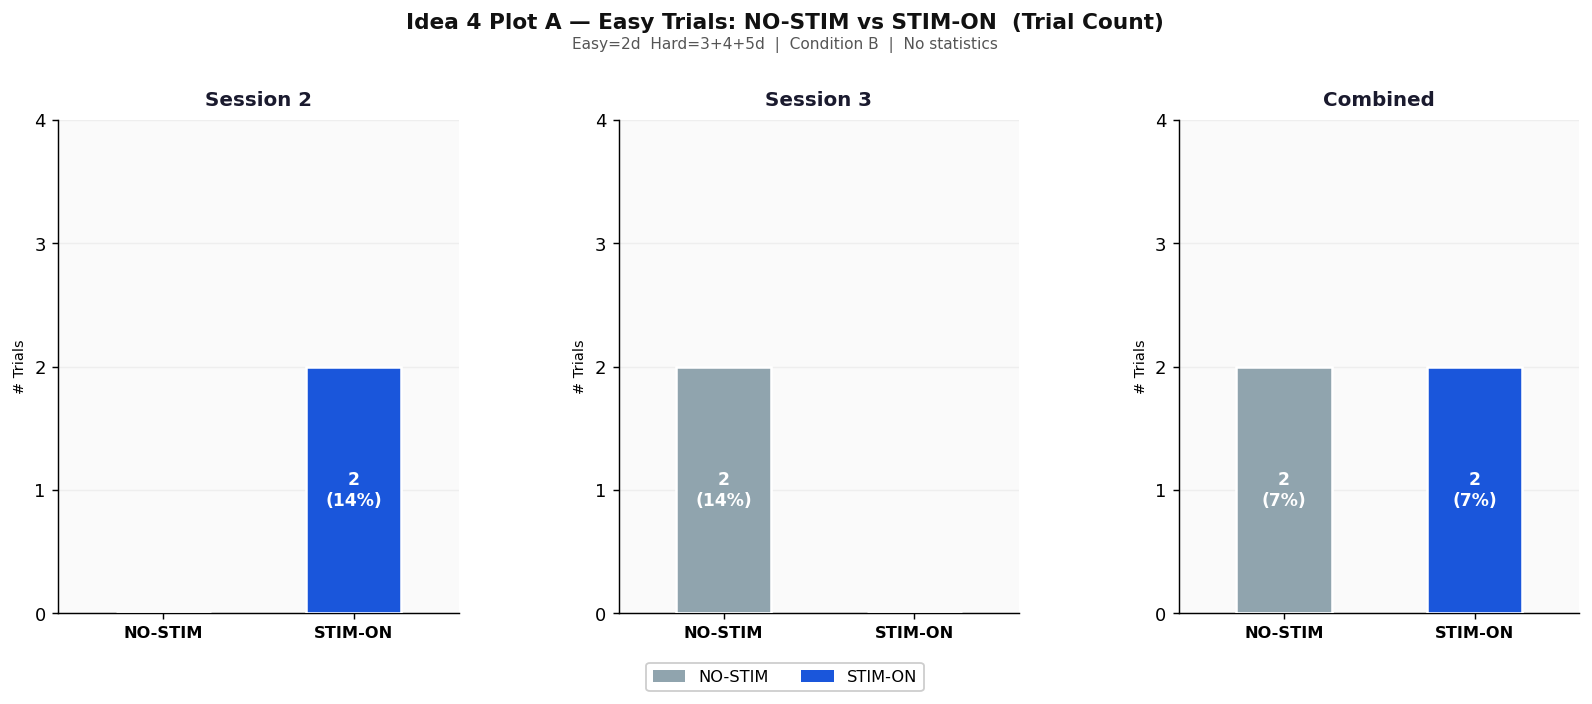

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\idea_4_A_easy_count.png


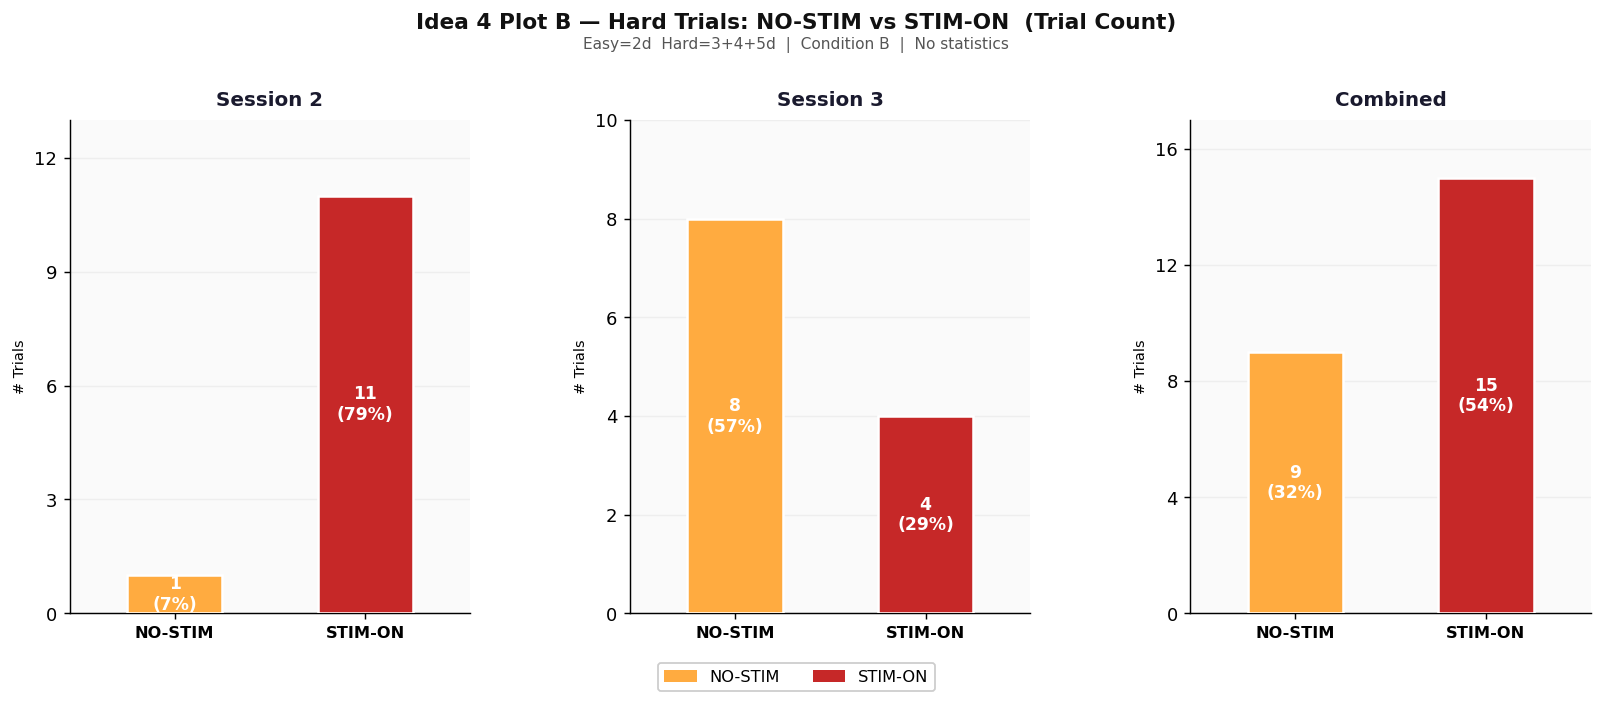

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\idea_4_B_hard_count.png


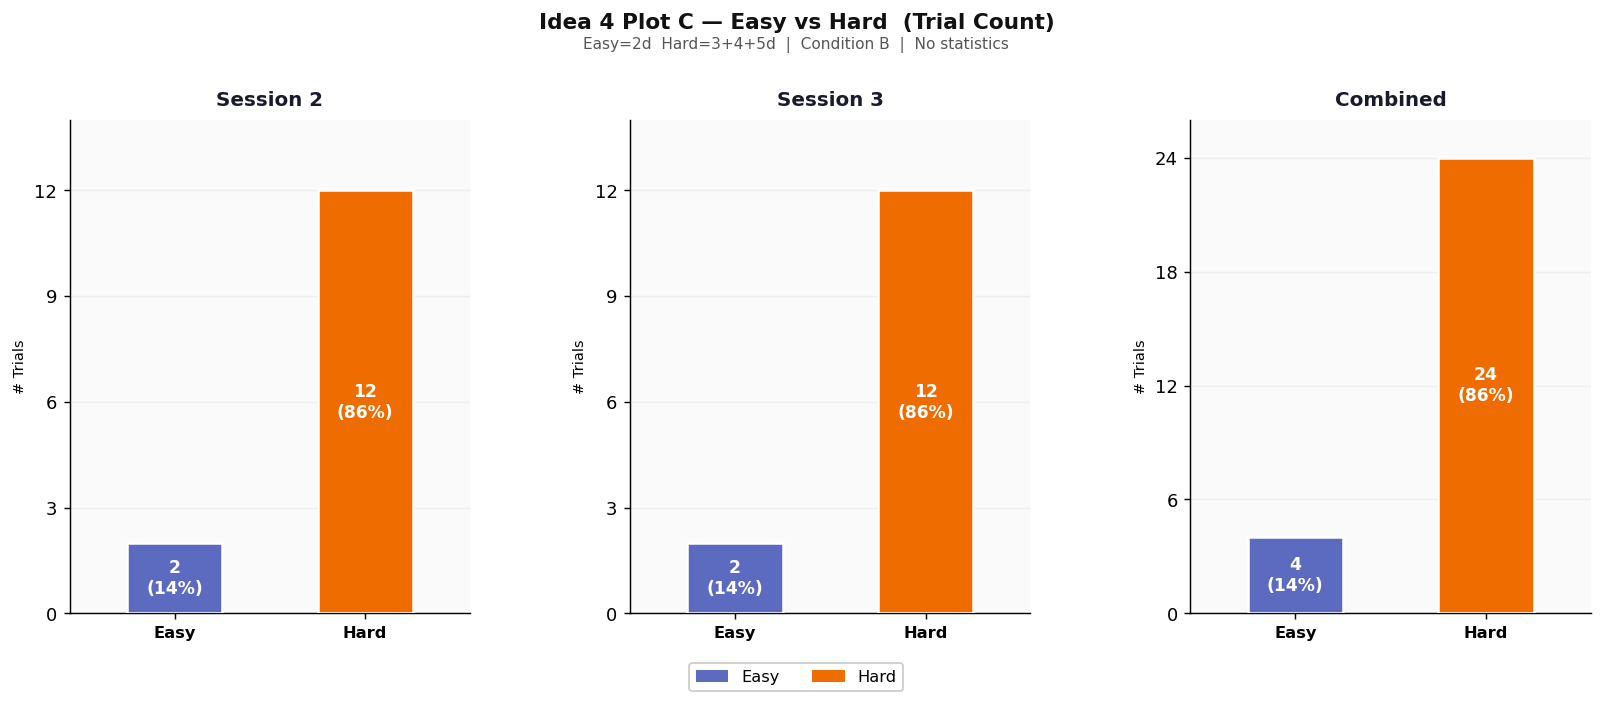

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\idea_4_C_easy_vs_hard_count.png


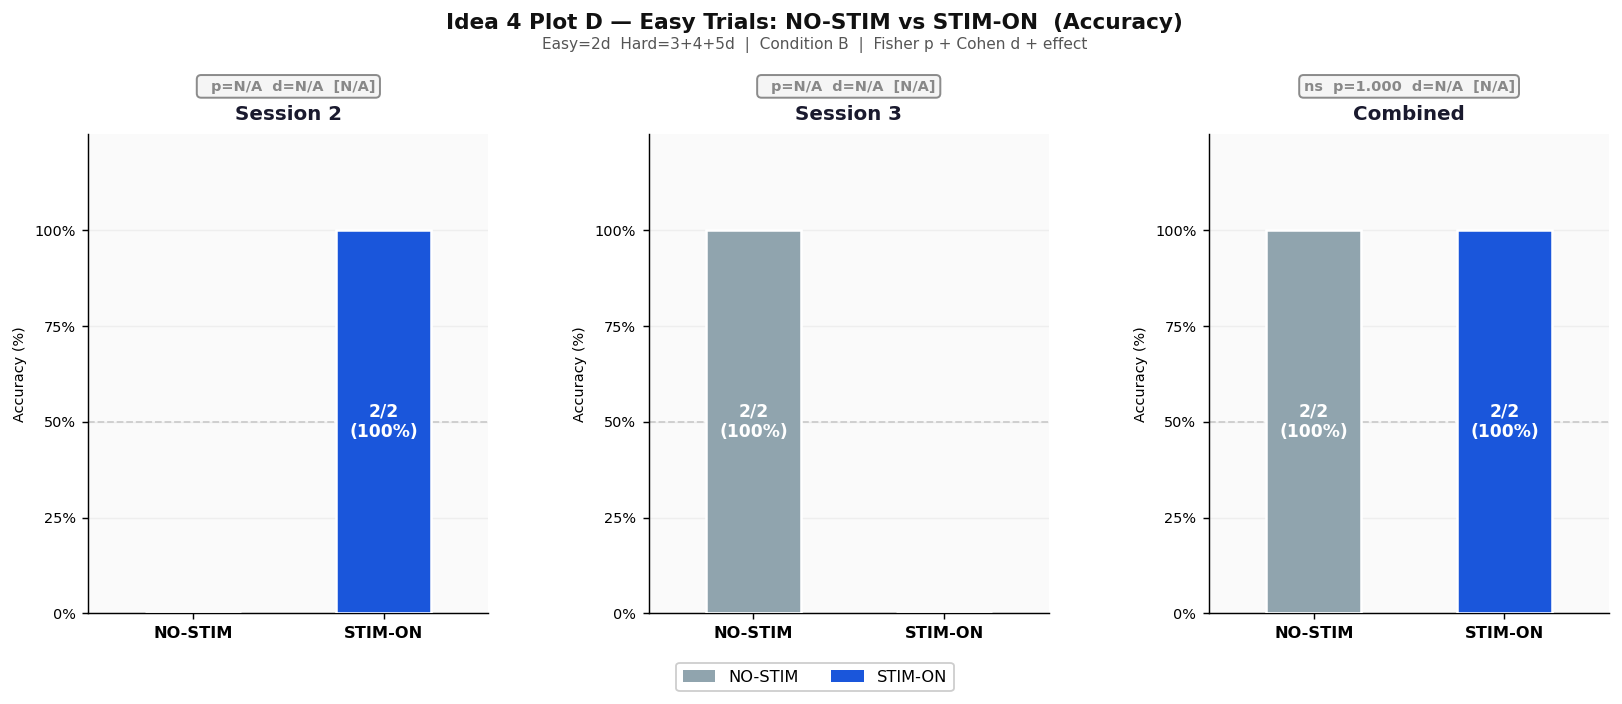

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\idea_4_D_easy_acc.png


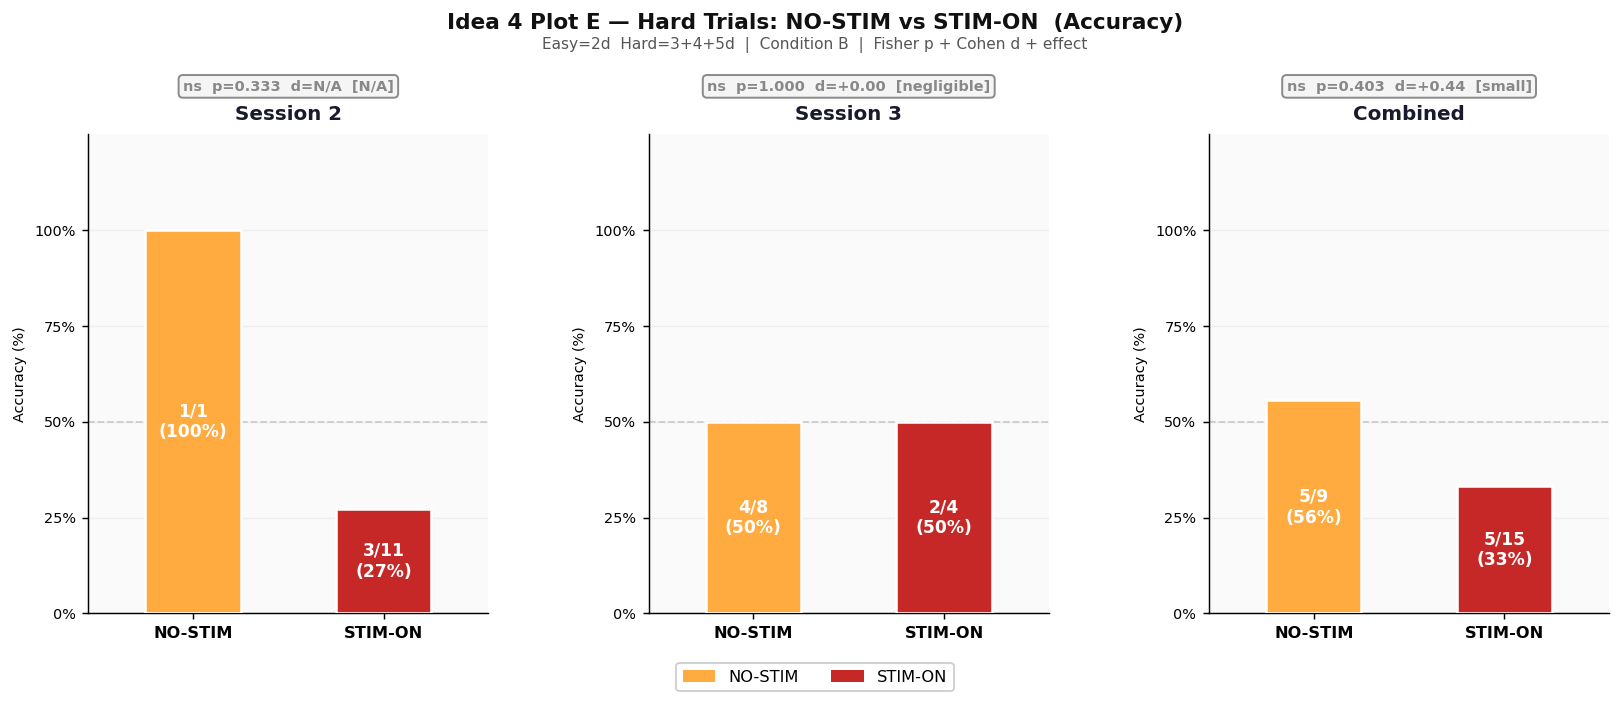

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\idea_4_E_hard_acc.png


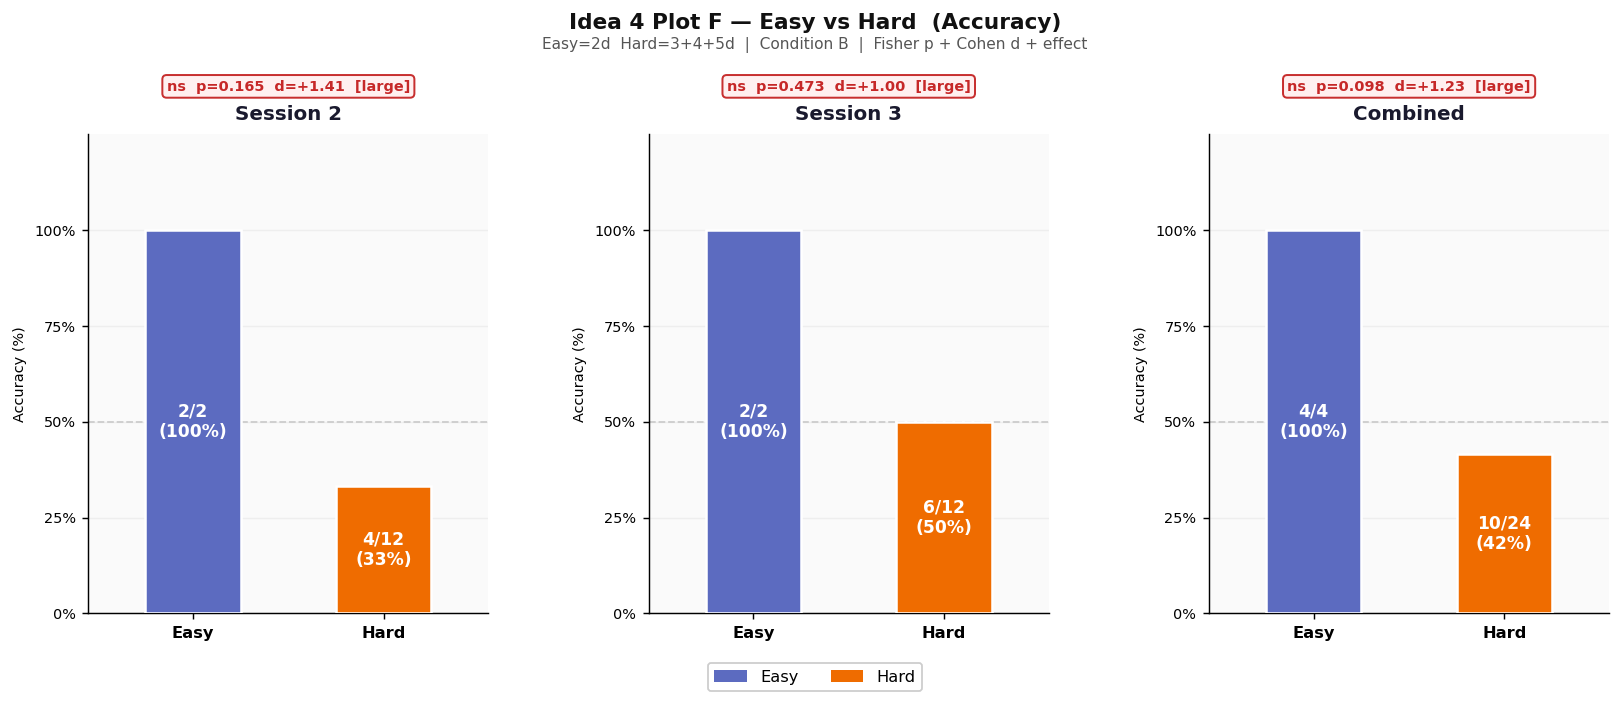

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\idea_4_F_easy_vs_hard_acc.png


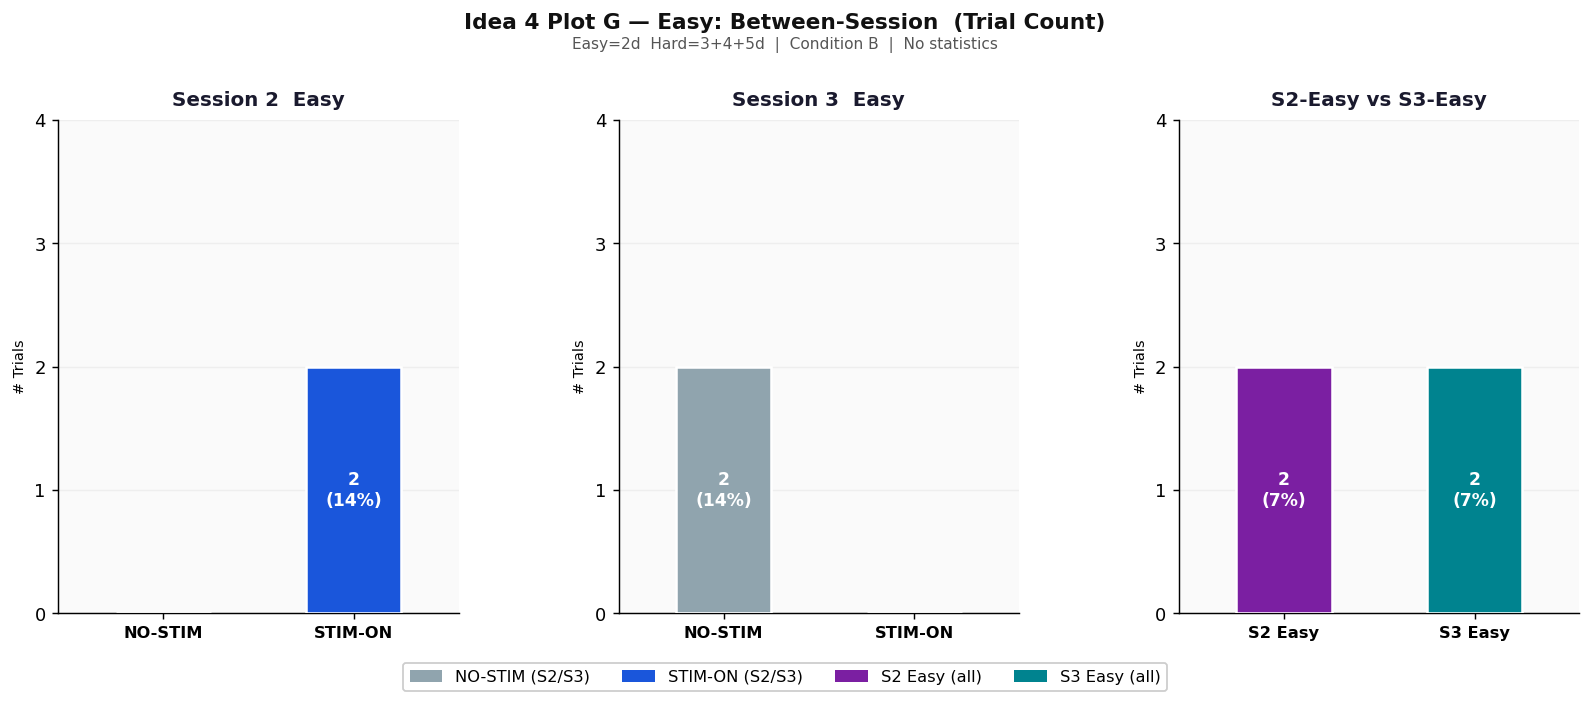

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\idea_4_G_easy_between_count.png


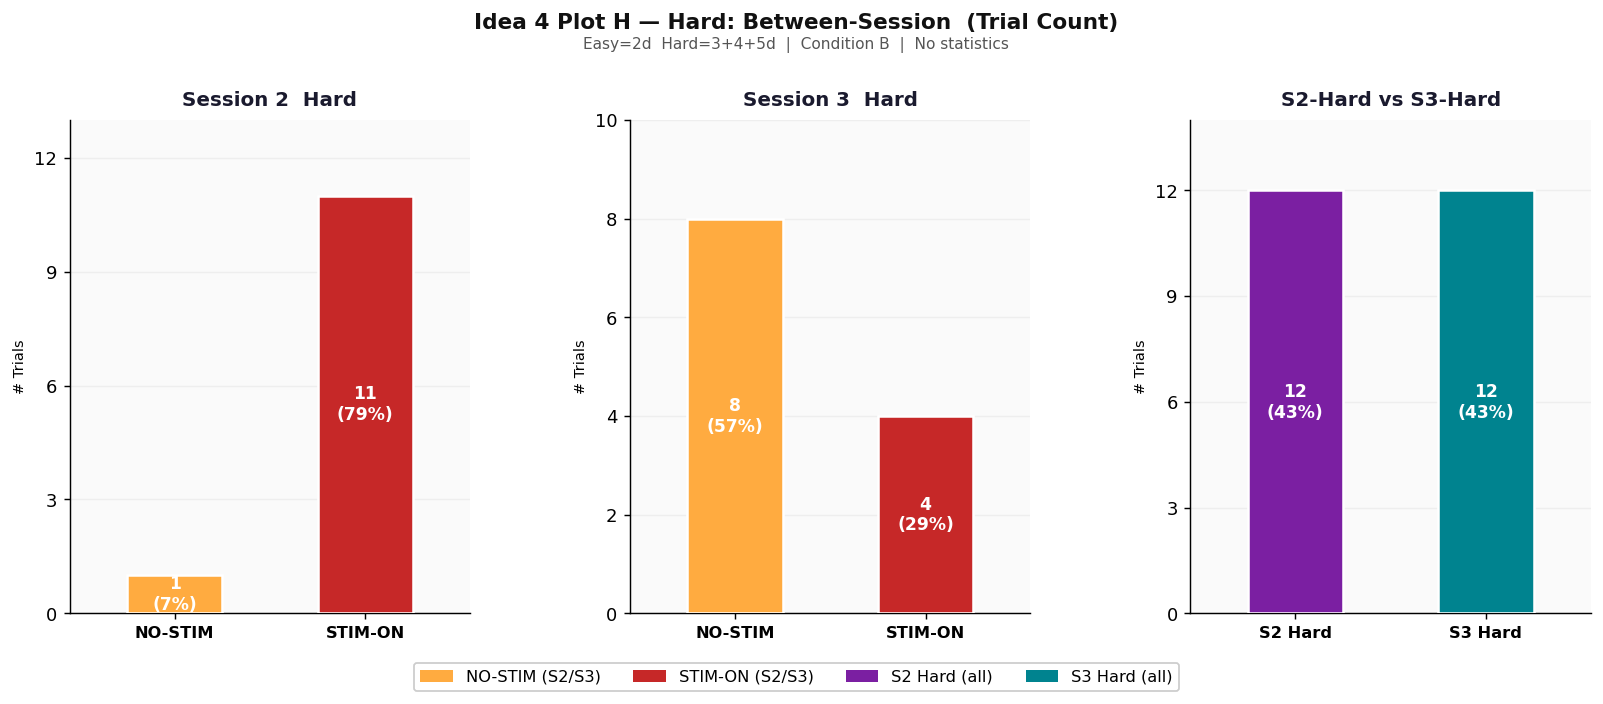

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\idea_4_H_hard_between_count.png


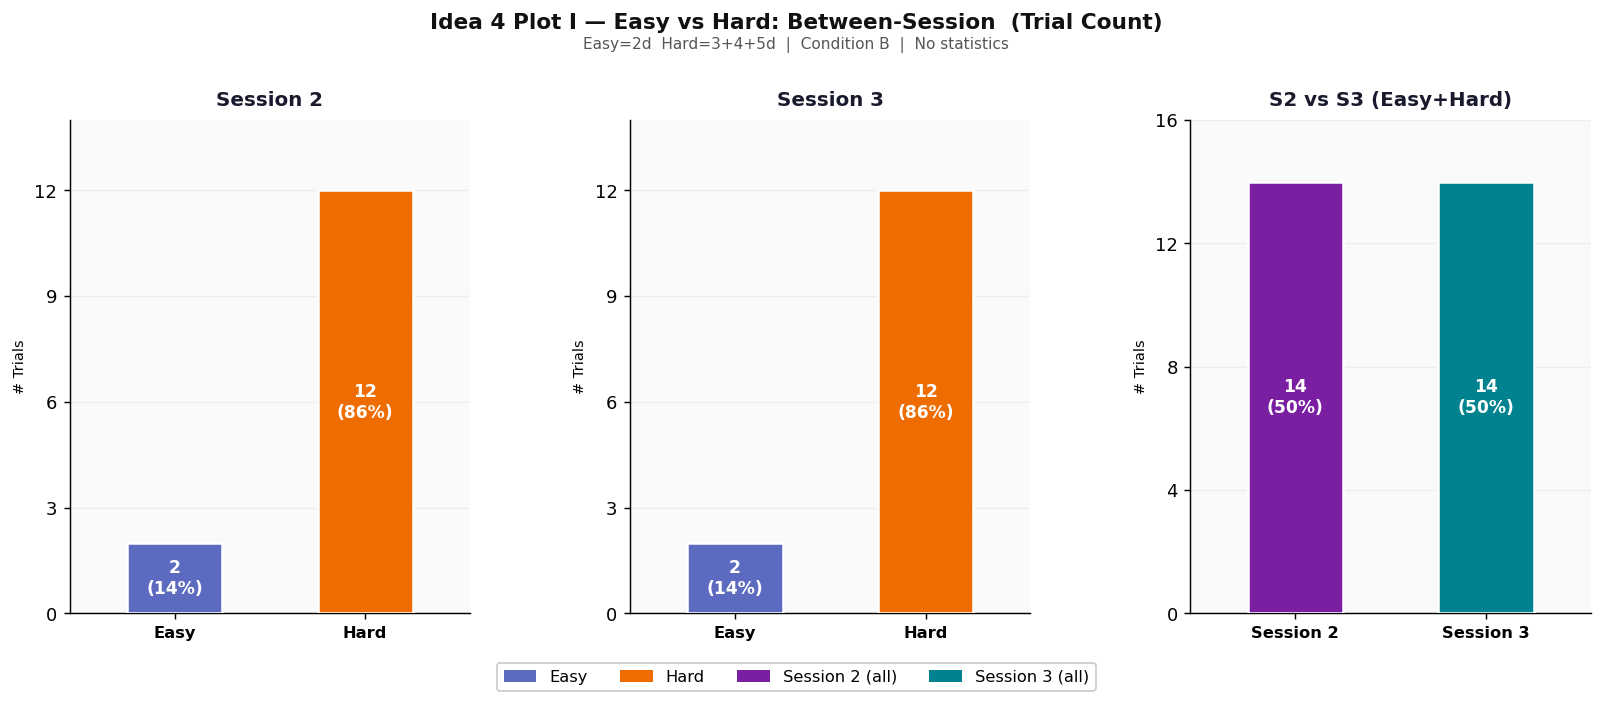

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\idea_4_I_between_easy_hard_count.png


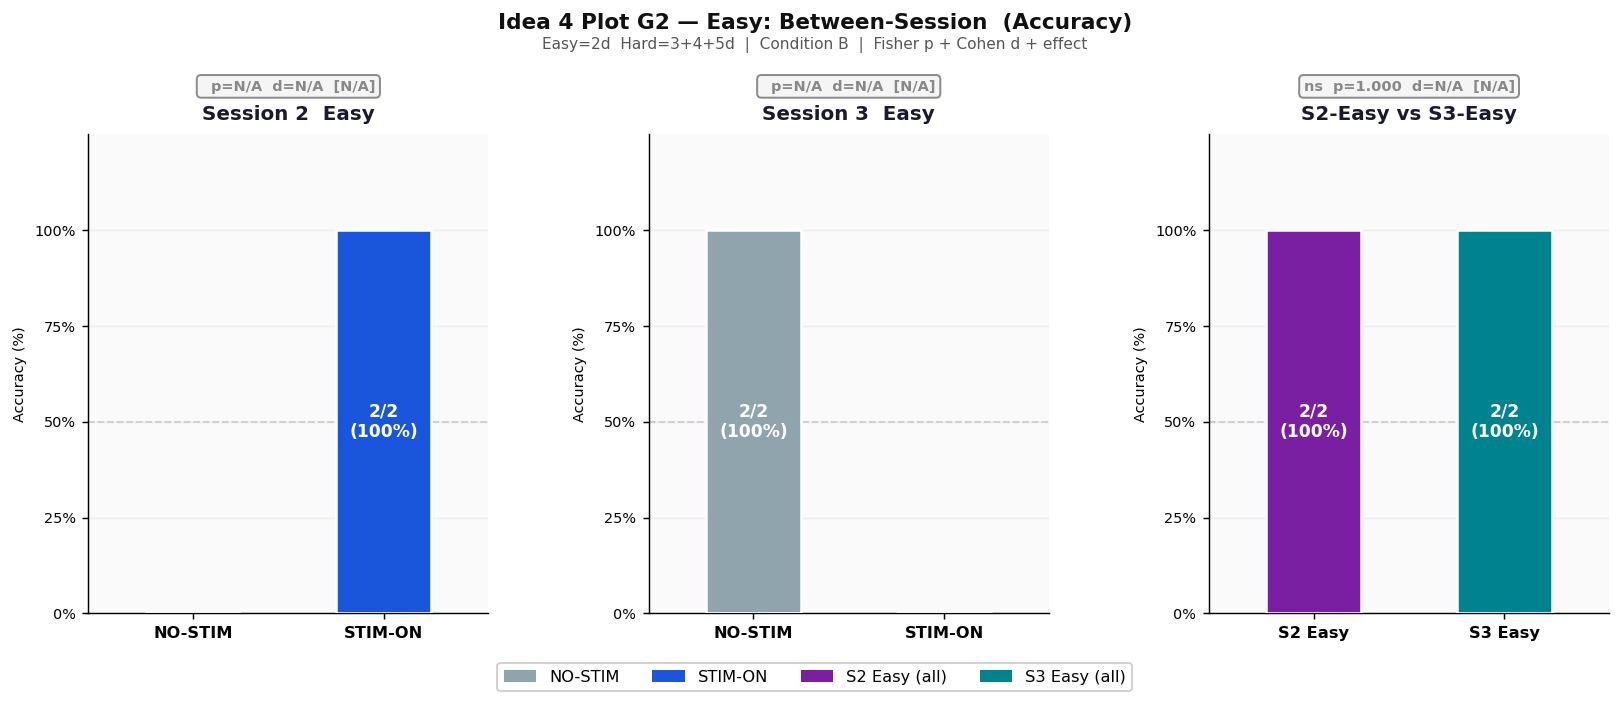

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\idea_4_G2_easy_between_acc.png


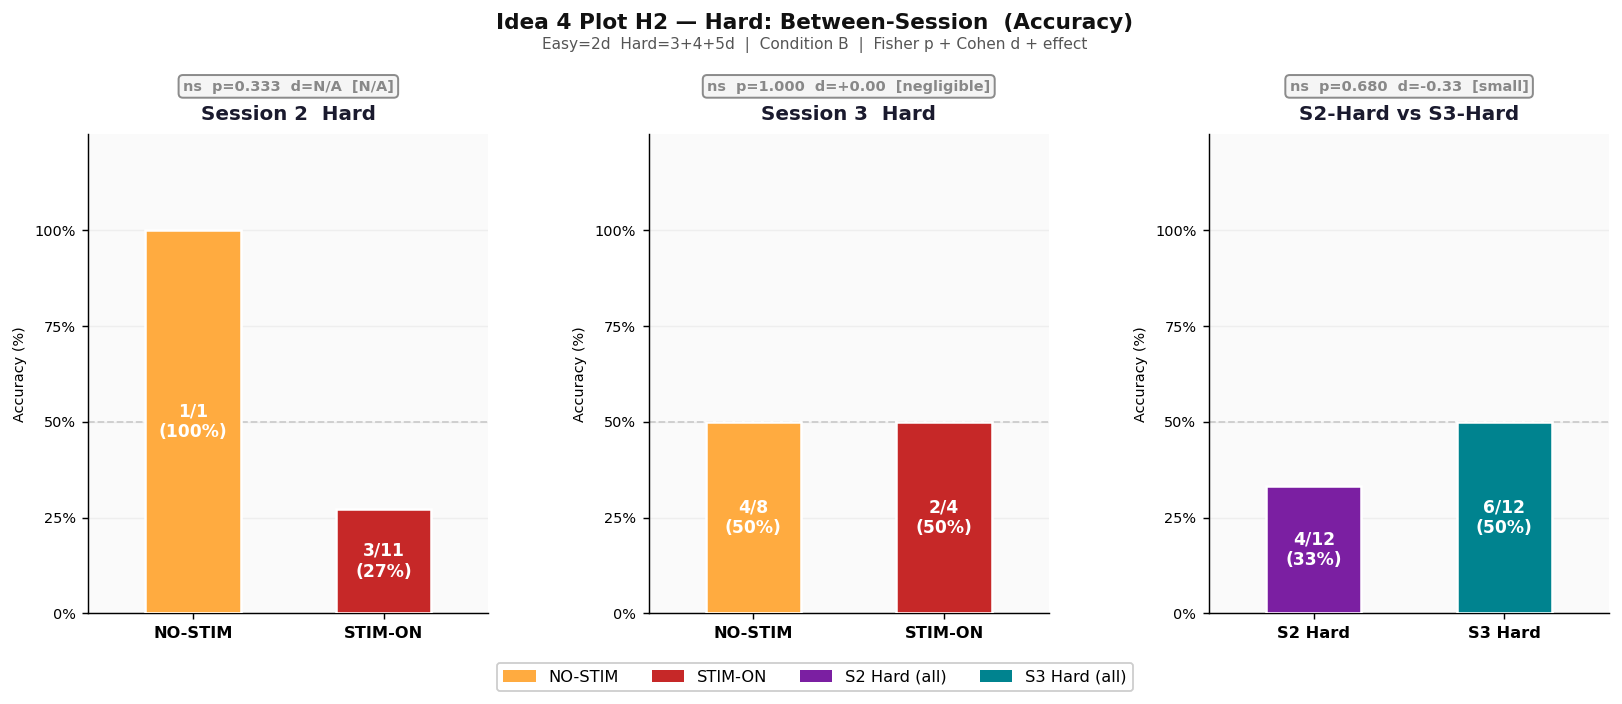

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\idea_4_H2_hard_between_acc.png


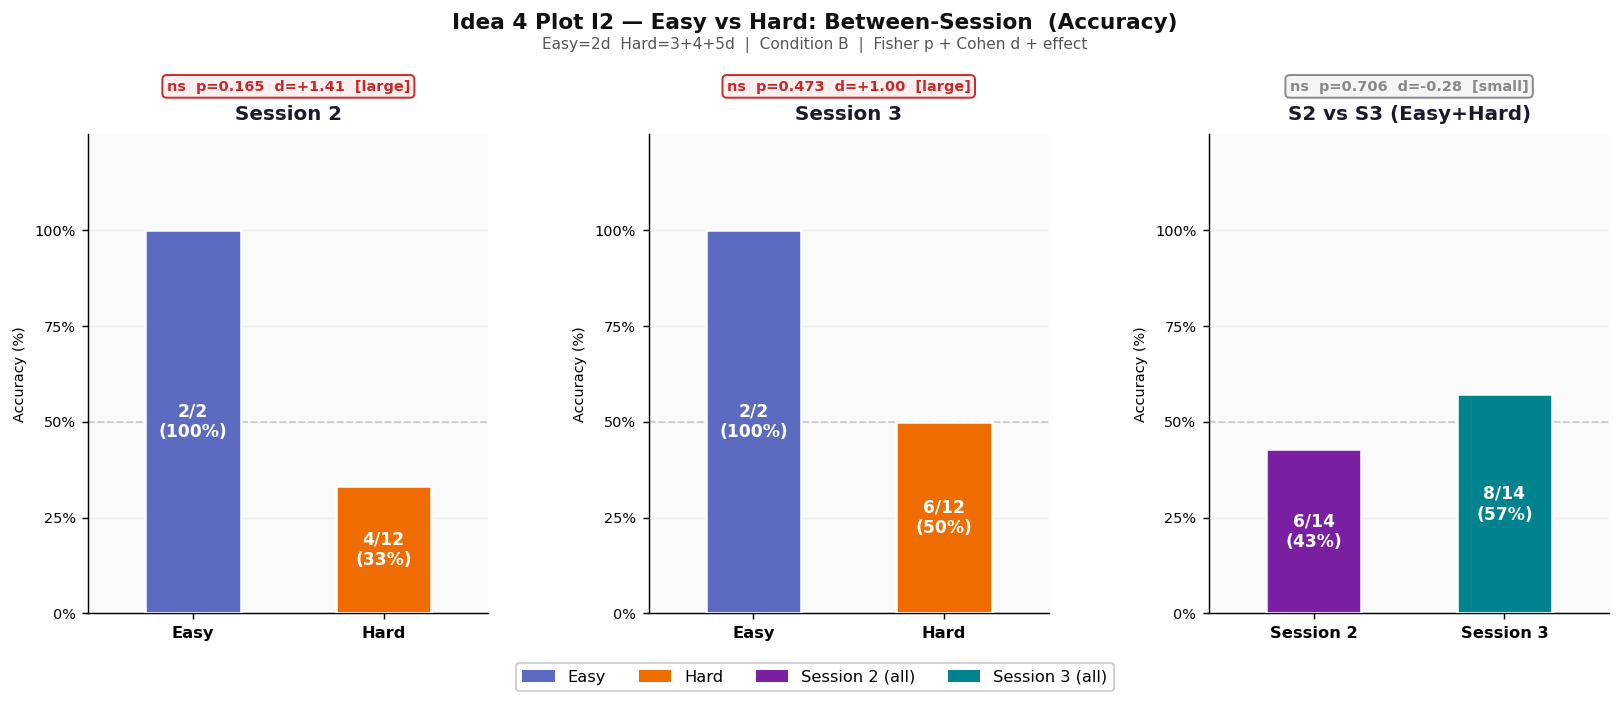

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\idea_4_I2_between_easy_hard_acc.png


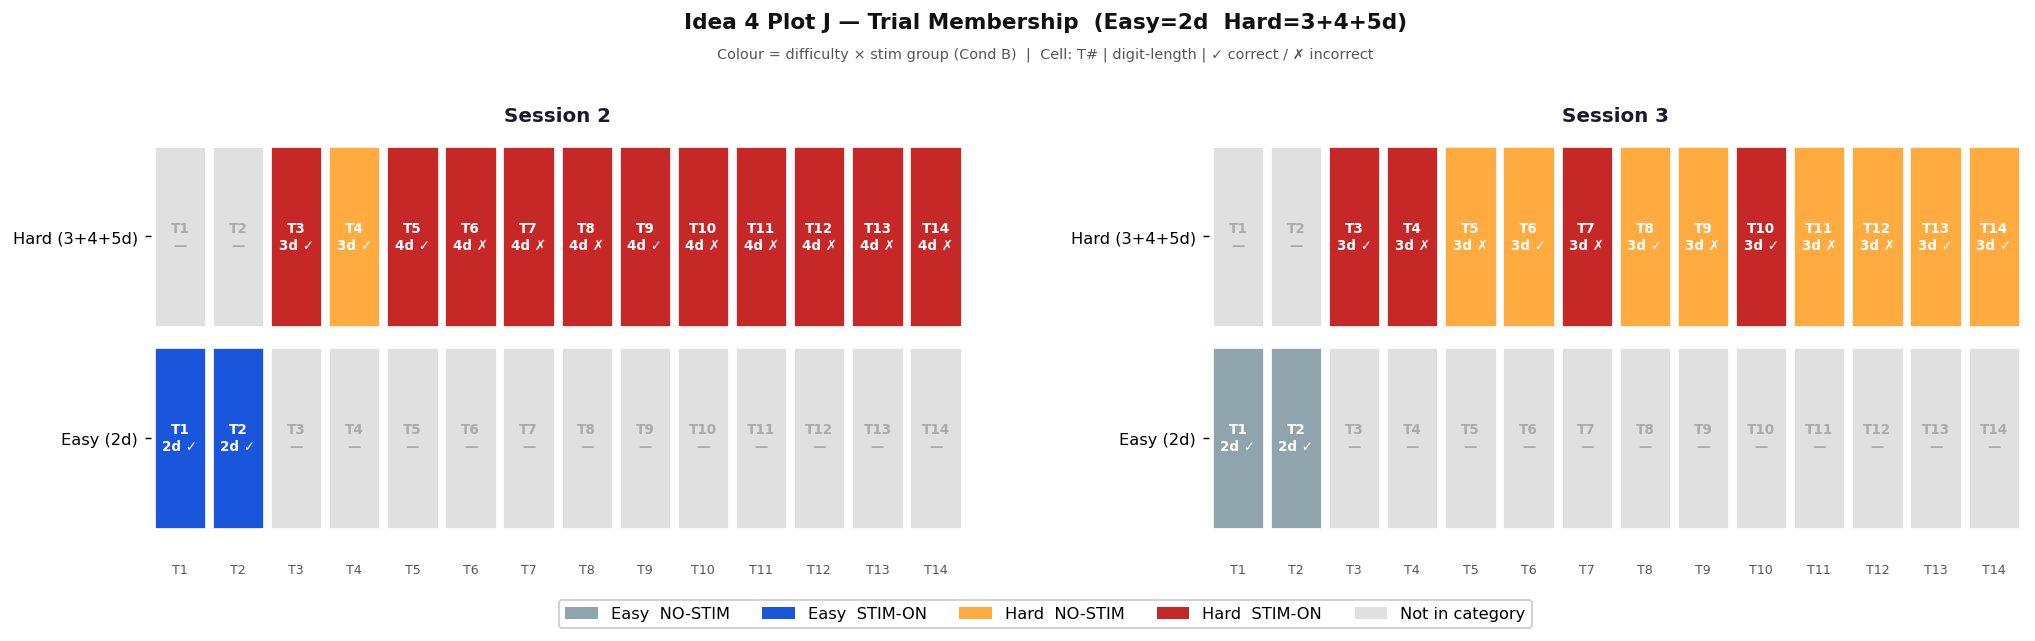

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\idea_4_J_membership.png


In [12]:
run_idea({2}, {3,4,5}, 'Idea 4', COMBINED_DIR)
